# Initial Testing — Learned Joint Relationship Model

Loads the best trained checkpoint, builds a lookup table from training data,
then runs a **pair retrieval** experiment on held-out test sequences:

> Given a pair of virtual-IMU windows from a test sequence, can the model identify
> which joint pair `(i, j)` they belong to by nearest-neighbour lookup in the table?

Metrics reported: **Top-1 accuracy**, **Top-5 accuracy**, **Mean Reciprocal Rank (MRR)**,
plus confusion heatmaps and per-pair error analysis.

In [1]:
import sys
sys.path.insert(0, '..')

import math
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm.auto import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT          = Path('../parsed_30gigs')
TRAIN_DIR     = ROOT / 'DIP_IMU_train_real_imu_position_only'
TEST_DIR      = ROOT / 'DIP_IMU_test_real_imu_position_only'
CKPT_PATH     = Path('.') / 'joint_rel_model_best.pt'

train_files = sorted(TRAIN_DIR.glob('*.pt'))
test_files  = sorted(TEST_DIR.glob('*.pt'))

print(f'Train files : {len(train_files)}')
print(f'Test  files : {len(test_files)}')
print(f'Checkpoint  : {CKPT_PATH}  (exists={CKPT_PATH.exists()})')

# ── SMPL joint names ──────────────────────────────────────────────────────────
JOINT_NAMES = [
    'pelvis', 'left_hip', 'right_hip', 'spine1',
    'left_knee', 'right_knee', 'spine2',
    'left_ankle', 'right_ankle', 'spine3',
    'left_foot', 'right_foot', 'neck',
    'left_collar', 'right_collar', 'head',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_hand', 'right_hand',
]
N_JOINTS = 24

SMPL_EDGES = [
    (0,1),(0,2),(0,3),(1,4),(2,5),(3,6),(4,7),(5,8),(6,9),
    (7,10),(8,11),(9,12),(9,13),(9,14),(12,15),
    (13,16),(14,17),(16,18),(17,19),(18,20),(19,21),(20,22),(21,23),
]
ADJACENT = {(i,j) for i,j in SMPL_EDGES} | {(j,i) for i,j in SMPL_EDGES}

# all unique ordered pairs — the 276 classes the model must distinguish
PAIRS = [(i, j) for i in range(N_JOINTS) for j in range(i+1, N_JOINTS)]
PAIR_TO_IDX = {p: k for k, p in enumerate(PAIRS)}
print(f'Unique joint pairs: {len(PAIRS)}')

# 17 real IMU sensor → SMPL joint index mapping
IMU_JOINTS = [7, 8, 10, 11, 20, 21, 0, 2, 5, 17, 19, 1, 4, 16, 18, 15, 9]
IMU_NAMES  = [JOINT_NAMES[j] for j in IMU_JOINTS]
print(f'IMU joints: {IMU_NAMES}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Train files : 885
Test  files : 19
Checkpoint  : joint_rel_model_best.pt  (exists=True)
Unique joint pairs: 276
IMU joints: ['left_ankle', 'right_ankle', 'left_foot', 'right_foot', 'left_wrist', 'right_wrist', 'pelvis', 'right_hip', 'right_knee', 'right_shoulder', 'right_elbow', 'left_hip', 'left_knee', 'left_shoulder', 'left_elbow', 'head', 'spine3']
Device: cpu


/Users/aliasgar/Desktop/Ali Asgar/Projects/IMUCOCO/IMUCoCo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1 — Model Definition + Load Checkpoint

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=300, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class JointEncoder(nn.Module):
    def __init__(self, in_channels=9, d_model=128, n_heads=4,
                 n_layers=2, d_embed=64, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.pool_proj   = nn.Linear(d_model, d_embed)

    def forward(self, x):
        x = self.pos_enc(self.input_proj(x))
        x = self.transformer(x)
        return F.normalize(self.pool_proj(x.mean(dim=1)), dim=-1)


class PairRelationshipHead(nn.Module):
    def __init__(self, d_embed=64, d_out=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_embed * 4, 256), nn.ReLU(), nn.Linear(256, d_out),
        )

    def forward(self, e_i, e_j):
        combined = torch.cat([e_i, e_j, (e_i - e_j).abs(), e_i * e_j], dim=-1)
        return F.normalize(self.mlp(combined), dim=-1)


class JointRelationshipModel(nn.Module):
    def __init__(self, d_embed=64):
        super().__init__()
        self.encoder  = JointEncoder(d_embed=d_embed)
        self.rel_head = PairRelationshipHead(d_embed=d_embed, d_out=d_embed)

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x_i, x_j):
        return self.rel_head(self.encoder(x_i), self.encoder(x_j))

    @torch.no_grad()
    def build_lookup_table(self, vimu):
        """vimu: [T, 24, 9] → [24, 24, d_embed]"""
        T, N, C = vimu.shape
        embeddings = self.encoder(vimu.permute(1, 0, 2))   # [24, d_embed]
        table = torch.zeros(N, N, embeddings.size(-1))
        for i in range(N):
            for j in range(N):
                table[i, j] = self.rel_head(
                    embeddings[i].unsqueeze(0),
                    embeddings[j].unsqueeze(0),
                ).squeeze(0)
        return table


# ── Load checkpoint ───────────────────────────────────────────────────────────
assert CKPT_PATH.exists(), f'Checkpoint not found at {CKPT_PATH} — run training.ipynb first'

ckpt    = torch.load(CKPT_PATH, map_location=device, weights_only=False)
d_embed = ckpt['d_embed']

model = JointRelationshipModel(d_embed=d_embed).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f'Loaded checkpoint')
print(f'  epoch    : {ckpt["epoch"]}')
print(f'  val_loss : {ckpt["val_loss"]:.5f}')
print(f'  d_embed  : {d_embed}')

Loaded checkpoint
  epoch    : 22
  val_loss : 4.19302
  d_embed  : 64


---
## 2 — Build Lookup Table from Training Data

Average `[24, 24, 64]` relationship embeddings across **all 885 training files**
using Welford's online algorithm — mean and std are accumulated one file at a time
so memory stays constant regardless of how many files are used.

In [3]:
# Use every training file for the most stable possible gallery
table_build_files = train_files   # all 885

# Welford online mean + M2 accumulator — [24, 24, d_embed]
# Avoids storing all tables simultaneously (saves ~120 MB)
wf_count = 0
wf_mean  = np.zeros((N_JOINTS, N_JOINTS, d_embed), dtype=np.float64)
wf_M2    = np.zeros((N_JOINTS, N_JOINTS, d_embed), dtype=np.float64)

with torch.no_grad():
    for fpath in tqdm(table_build_files, desc='Building lookup table (all train files)'):
        data  = torch.load(fpath, map_location='cpu', weights_only=False)
        vimu  = data['vimu']['vimu_joints'].to(device)              # [300, 24, 9]
        table = model.build_lookup_table(vimu).cpu().numpy()        # [24, 24, 64]

        wf_count += 1
        delta      = table - wf_mean
        wf_mean   += delta / wf_count
        delta2     = table - wf_mean
        wf_M2     += delta * delta2

table_mean = wf_mean.astype(np.float32)                            # [24, 24, 64]
table_std  = np.sqrt(wf_M2 / max(wf_count - 1, 1)).astype(np.float32)  # [24, 24, 64]

# Pre-flatten the 276 unique pair vectors for fast retrieval
gallery        = np.stack([table_mean[i, j] for i, j in PAIRS])   # [276, 64]
gallery_norms  = np.linalg.norm(gallery, axis=-1, keepdims=True) + 1e-8
gallery_normed = gallery / gallery_norms                            # [276, 64]

print(f'Files used    : {wf_count} / {len(train_files)} train files')
print(f'Lookup table  : {table_mean.shape}')
print(f'Gallery       : {gallery_normed.shape}  (276 pairs × {d_embed}-D)')
print(f'Value range   : [{table_mean.min():.4f}, {table_mean.max():.4f}]')
print(f'Mean entry std: {table_std.mean():.4f}  (consistency across sequences)')

Building lookup table (all train files): 100%|██████████| 885/885 [00:36<00:00, 24.25it/s]

Files used    : 885 / 885 train files
Lookup table  : (24, 24, 64)
Gallery       : (276, 64)  (276 pairs × 64-D)
Value range   : [-0.3224, 0.3114]
Mean entry std: 0.0181  (consistency across sequences)


---
## 3 — Retrieval Helper

For a query embedding, find the top-K nearest pairs in the gallery by cosine similarity.

In [4]:
def retrieve_topk(query_emb: np.ndarray, k: int = 5):
    """
    query_emb: [64]  L2-normalised relationship embedding
    Returns: list of (cos_sim, pair_idx, (i, j)) sorted by decreasing similarity
    """
    sims = gallery_normed @ query_emb           # [276]
    topk_idx = np.argsort(sims)[::-1][:k]
    return [(float(sims[idx]), idx, PAIRS[idx]) for idx in topk_idx]


def get_query_embedding(vimu_seq: torch.Tensor, i: int, j: int) -> np.ndarray:
    """
    vimu_seq: [T, 24, 9]  full sequence
    Returns L2-normalised relationship embedding for pair (i, j).
    """
    with torch.no_grad():
        xi = vimu_seq[:, i, :].unsqueeze(0).to(device)   # [1, T, 9]
        xj = vimu_seq[:, j, :].unsqueeze(0).to(device)   # [1, T, 9]
        emb = model(xi, xj).squeeze(0).cpu().numpy()     # [64]
    norm = np.linalg.norm(emb) + 1e-8
    return emb / norm

# ── Sanity check on one test file ────────────────────────────────────────────
d0   = torch.load(test_files[0], map_location='cpu', weights_only=False)
vimu0 = d0['vimu']['vimu_joints']   # [T, 24, 9]

# take a 300-frame window
T_WINDOW = 300
vimu_window = vimu0[:T_WINDOW]

# query pair (right_shoulder=17, right_elbow=19)
q_emb = get_query_embedding(vimu_window, 17, 19)
top5  = retrieve_topk(q_emb, k=5)

print(f'Query: (right_shoulder, right_elbow)  →  top-5 retrieved pairs:')
for rank, (sim, idx, (pi, pj)) in enumerate(top5, 1):
    correct = '✓' if (pi, pj) == (17, 19) else ' '
    print(f'  {rank}. ({JOINT_NAMES[pi]}, {JOINT_NAMES[pj]}){" "*(40-len(JOINT_NAMES[pi])-len(JOINT_NAMES[pj]))}  cos={sim:.4f}  {correct}')

Query: (right_shoulder, right_elbow)  →  top-5 retrieved pairs:
  1. (right_shoulder, right_elbow)                 cos=0.9982  ✓
  2. (right_shoulder, right_wrist)                 cos=0.9958   
  3. (right_collar, right_shoulder)                cos=0.9937   
  4. (right_elbow, right_wrist)                    cos=0.9923   
  5. (right_elbow, right_hand)                     cos=0.9892   


---
## 4 — Full Pair Retrieval Evaluation on All Test Sequences

For every test file we sample a 300-frame window, query every unique pair `(i, j)`,
and record whether the correct pair is retrieved at rank 1, 5, or 10.

In [5]:
T_WINDOW = 300   # window length fed to the model

# per-pair stats across all test files
pair_hits   = {p: {'top1': 0, 'top5': 0, 'top10': 0, 'rr': [], 'n': 0} for p in PAIRS}
global_hits = {'top1': 0, 'top5': 0, 'top10': 0}
all_rr      = []
n_queries   = 0

# confusion: true_pair_idx → predicted_pair_idx count
confusion = np.zeros((len(PAIRS), len(PAIRS)), dtype=np.int32)

for fpath in tqdm(test_files, desc='Evaluating test files'):
    data  = torch.load(fpath, map_location='cpu', weights_only=False)
    vimu  = data['vimu']['vimu_joints']   # [T, 24, 9]
    T_seq = vimu.shape[0]

    # take a random 300-frame window from the sequence
    start  = random.randint(0, max(0, T_seq - T_WINDOW))
    window = vimu[start: start + T_WINDOW]   # [300, 24, 9]

    with torch.no_grad():
        # encode all 24 joints at once → [24, d_embed]
        x_all = window.permute(1, 0, 2).to(device)        # [24, 300, 9]
        embs  = model.encode(x_all).cpu().numpy()          # [24, 64]
        embs  = embs / (np.linalg.norm(embs, axis=-1, keepdims=True) + 1e-8)

    for true_idx, (i, j) in enumerate(PAIRS):
        # relationship embedding via head
        e_i = torch.from_numpy(embs[i]).unsqueeze(0).to(device)
        e_j = torch.from_numpy(embs[j]).unsqueeze(0).to(device)
        with torch.no_grad():
            q_emb = model.rel_head(e_i, e_j).squeeze(0).cpu().numpy()
        q_emb = q_emb / (np.linalg.norm(q_emb) + 1e-8)

        sims     = gallery_normed @ q_emb              # [276]
        ranked   = np.argsort(sims)[::-1]              # descending
        pred_idx = int(ranked[0])

        # rank of correct pair (1-indexed)
        rank = int(np.where(ranked == true_idx)[0][0]) + 1
        rr   = 1.0 / rank

        pair_hits[(i,j)]['n']   += 1
        pair_hits[(i,j)]['rr'].append(rr)
        if rank == 1:  pair_hits[(i,j)]['top1']  += 1
        if rank <= 5:  pair_hits[(i,j)]['top5']  += 1
        if rank <= 10: pair_hits[(i,j)]['top10'] += 1

        global_hits['top1']  += (rank == 1)
        global_hits['top5']  += (rank <= 5)
        global_hits['top10'] += (rank <= 10)
        all_rr.append(rr)
        n_queries += 1

        confusion[true_idx, pred_idx] += 1

print(f'\nTotal queries : {n_queries}  ({len(test_files)} files × {len(PAIRS)} pairs)')
print(f'Top-1  accuracy : {global_hits["top1"]/n_queries*100:.2f}%')
print(f'Top-5  accuracy : {global_hits["top5"]/n_queries*100:.2f}%')
print(f'Top-10 accuracy : {global_hits["top10"]/n_queries*100:.2f}%')
print(f'MRR             : {np.mean(all_rr):.4f}')
print(f'Chance baseline : top-1 = {1/len(PAIRS)*100:.2f}%  top-5 = {5/len(PAIRS)*100:.2f}%')

Evaluating test files: 100%|██████████| 19/19 [00:02<00:00,  8.86it/s]


Total queries : 5244  (19 files × 276 pairs)
Top-1  accuracy : 21.80%
Top-5  accuracy : 59.59%
Top-10 accuracy : 76.37%
MRR             : 0.3888
Chance baseline : top-1 = 0.36%  top-5 = 1.81%


---
## 5 — Metrics Visualisation

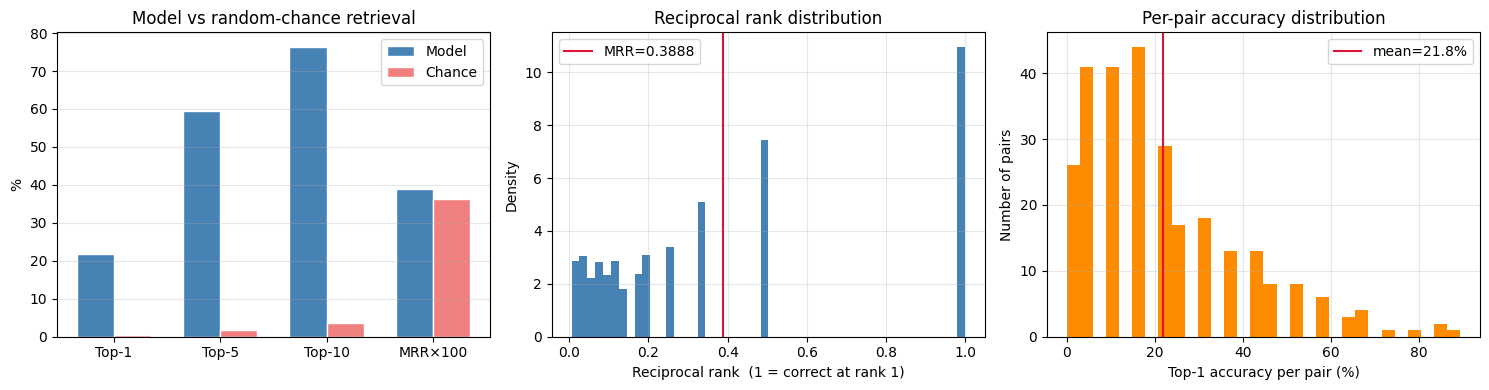

In [6]:
top1_global  = global_hits['top1']  / n_queries * 100
top5_global  = global_hits['top5']  / n_queries * 100
top10_global = global_hits['top10'] / n_queries * 100
mrr_global   = np.mean(all_rr) * 100
chance_top1  = 1 / len(PAIRS) * 100
chance_top5  = 5 / len(PAIRS) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Bar: model vs chance ──────────────────────────────────────────────────────
labels  = ['Top-1', 'Top-5', 'Top-10', 'MRR×100']
model_v = [top1_global, top5_global, top10_global, mrr_global]
chance_v= [chance_top1, chance_top5, 10/len(PAIRS)*100, 1/len(PAIRS)*100*100]
x = np.arange(len(labels))
w = 0.35
axes[0].bar(x - w/2, model_v,  w, label='Model',  color='steelblue',  edgecolor='white')
axes[0].bar(x + w/2, chance_v, w, label='Chance', color='lightcoral', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('%')
axes[0].set_title('Model vs random-chance retrieval')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── Reciprocal rank distribution ──────────────────────────────────────────────
axes[1].hist(all_rr, bins=50, color='steelblue', edgecolor='none', density=True)
axes[1].axvline(np.mean(all_rr), color='crimson', lw=1.5, label=f'MRR={np.mean(all_rr):.4f}')
axes[1].set_xlabel('Reciprocal rank  (1 = correct at rank 1)')
axes[1].set_ylabel('Density')
axes[1].set_title('Reciprocal rank distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Per-pair top-1 accuracy distribution ─────────────────────────────────────
pair_top1_rates = [
    pair_hits[p]['top1'] / pair_hits[p]['n'] * 100
    for p in PAIRS if pair_hits[p]['n'] > 0
]
axes[2].hist(pair_top1_rates, bins=30, color='darkorange', edgecolor='none')
axes[2].axvline(np.mean(pair_top1_rates), color='crimson', lw=1.5,
                label=f'mean={np.mean(pair_top1_rates):.1f}%')
axes[2].set_xlabel('Top-1 accuracy per pair (%)')
axes[2].set_ylabel('Number of pairs')
axes[2].set_title('Per-pair accuracy distribution')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6 — Real IMU Sensor Pair Evaluation

The 17 physical IMU sensors cover a specific subset of SMPL joints.
Here we restrict to the **136 unique sensor pairs** that correspond to real hardware,
using `vimu_joints` at those joint positions.

In [7]:
# Unique sensor pairs (ordered so i < j in SMPL joint index space)
sensor_pairs = []
for a in range(len(IMU_JOINTS)):
    for b in range(a + 1, len(IMU_JOINTS)):
        i, j = sorted([IMU_JOINTS[a], IMU_JOINTS[b]])
        if (i, j) in PAIR_TO_IDX:
            sensor_pairs.append((i, j))
sensor_pairs = list(dict.fromkeys(sensor_pairs))   # deduplicate, keep order
print(f'Unique IMU sensor pairs: {len(sensor_pairs)}')

imu_hits  = {'top1': 0, 'top5': 0, 'top10': 0}
imu_rr    = []
imu_n     = 0
imu_pair_acc = {}

for fpath in tqdm(test_files, desc='IMU sensor pairs'):
    data   = torch.load(fpath, map_location='cpu', weights_only=False)
    vimu   = data['vimu']['vimu_joints']
    T_seq  = vimu.shape[0]
    start  = random.randint(0, max(0, T_seq - T_WINDOW))
    window = vimu[start: start + T_WINDOW]

    with torch.no_grad():
        x_all = window.permute(1, 0, 2).to(device)
        embs  = model.encode(x_all).cpu().numpy()
        embs  = embs / (np.linalg.norm(embs, axis=-1, keepdims=True) + 1e-8)

    for (i, j) in sensor_pairs:
        true_idx = PAIR_TO_IDX[(i, j)]
        e_i = torch.from_numpy(embs[i]).unsqueeze(0).to(device)
        e_j = torch.from_numpy(embs[j]).unsqueeze(0).to(device)
        with torch.no_grad():
            q_emb = model.rel_head(e_i, e_j).squeeze(0).cpu().numpy()
        q_emb = q_emb / (np.linalg.norm(q_emb) + 1e-8)

        sims   = gallery_normed @ q_emb
        ranked = np.argsort(sims)[::-1]
        rank   = int(np.where(ranked == true_idx)[0][0]) + 1
        rr     = 1.0 / rank

        imu_hits['top1']  += (rank == 1)
        imu_hits['top5']  += (rank <= 5)
        imu_hits['top10'] += (rank <= 10)
        imu_rr.append(rr)
        imu_n += 1
        imu_pair_acc.setdefault((i,j), []).append(rank == 1)

print(f'\nIMU sensor pairs — {imu_n} queries  ({len(test_files)} files × {len(sensor_pairs)} pairs)')
print(f'Top-1  accuracy : {imu_hits["top1"]/imu_n*100:.2f}%')
print(f'Top-5  accuracy : {imu_hits["top5"]/imu_n*100:.2f}%')
print(f'Top-10 accuracy : {imu_hits["top10"]/imu_n*100:.2f}%')
print(f'MRR             : {np.mean(imu_rr):.4f}')

Unique IMU sensor pairs: 136


IMU sensor pairs: 100%|██████████| 19/19 [00:01<00:00,  9.88it/s]


IMU sensor pairs — 2584 queries  (19 files × 136 pairs)
Top-1  accuracy : 16.72%
Top-5  accuracy : 49.38%
Top-10 accuracy : 66.64%
MRR             : 0.3195


---
## 7 — Per-Pair Accuracy Heatmap (all 276 pairs)

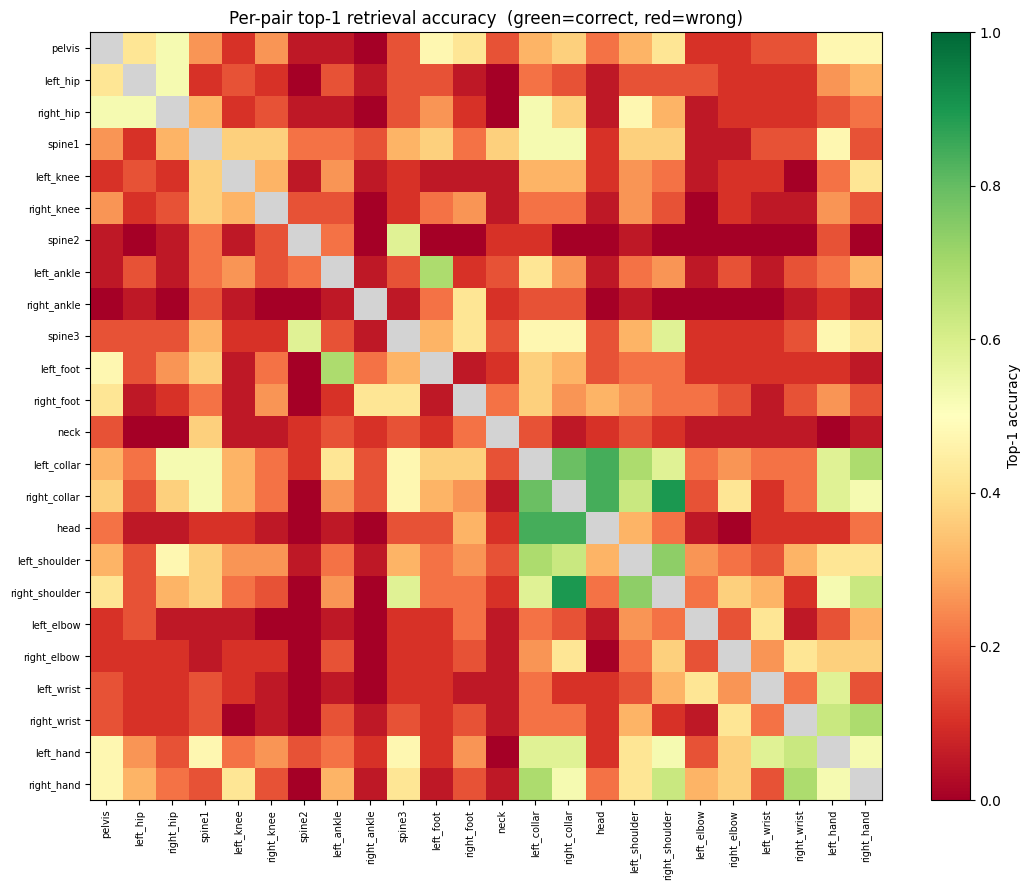

In [8]:
# Build [24, 24] accuracy matrix
acc_matrix = np.full((N_JOINTS, N_JOINTS), np.nan)
for (i, j), stats in pair_hits.items():
    if stats['n'] > 0:
        rate = stats['top1'] / stats['n']
        acc_matrix[i, j] = rate
        acc_matrix[j, i] = rate   # symmetric for display

fig, ax = plt.subplots(figsize=(11, 9))
cmap = plt.cm.RdYlGn
cmap.set_bad('lightgrey')
im = ax.imshow(acc_matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Top-1 accuracy')
ax.set_xticks(range(N_JOINTS))
ax.set_yticks(range(N_JOINTS))
ax.set_xticklabels(JOINT_NAMES, rotation=90, fontsize=7)
ax.set_yticklabels(JOINT_NAMES, fontsize=7)
ax.set_title('Per-pair top-1 retrieval accuracy  (green=correct, red=wrong)')
plt.tight_layout()
plt.show()

---
## 8 — Best and Worst Pairs

In [9]:
pair_acc_list = [
    (pair_hits[p]['top1'] / pair_hits[p]['n'], p)
    for p in PAIRS if pair_hits[p]['n'] > 0
]
pair_acc_list.sort(reverse=True)

TOP_N = 15
print(f'Top-{TOP_N} easiest pairs (highest top-1 accuracy):')
print(f'  {"Pair":<42}  Acc   Adjacent?')
print('  ' + '-' * 58)
for acc, (i, j) in pair_acc_list[:TOP_N]:
    adj = 'yes' if (i,j) in ADJACENT or (j,i) in ADJACENT else 'no'
    print(f'  ({JOINT_NAMES[i]}, {JOINT_NAMES[j]}){" "*(38-len(JOINT_NAMES[i])-len(JOINT_NAMES[j]))}  {acc*100:5.1f}%  {adj}')

print()
print(f'Top-{TOP_N} hardest pairs (lowest top-1 accuracy):')
print(f'  {"Pair":<42}  Acc   Adjacent?')
print('  ' + '-' * 58)
for acc, (i, j) in pair_acc_list[-TOP_N:][::-1]:
    adj = 'yes' if (i,j) in ADJACENT or (j,i) in ADJACENT else 'no'
    print(f'  ({JOINT_NAMES[i]}, {JOINT_NAMES[j]}){" "*(38-len(JOINT_NAMES[i])-len(JOINT_NAMES[j]))}  {acc*100:5.1f}%  {adj}')

# Accuracy by adjacency class
adj_accs  = [acc for acc, (i,j) in pair_acc_list if (i,j) in ADJACENT or (j,i) in ADJACENT]
nadj_accs = [acc for acc, (i,j) in pair_acc_list if not ((i,j) in ADJACENT or (j,i) in ADJACENT)]
print()
print(f'Adjacent pairs     ({len(adj_accs):>3} pairs):  mean top-1 = {np.mean(adj_accs)*100:.2f}%')
print(f'Non-adjacent pairs ({len(nadj_accs):>3} pairs):  mean top-1 = {np.mean(nadj_accs)*100:.2f}%')

Top-15 easiest pairs (highest top-1 accuracy):
  Pair                                        Acc   Adjacent?
  ----------------------------------------------------------
  (right_collar, right_shoulder)               89.5%  yes
  (right_collar, head)                         84.2%  no
  (left_collar, head)                          84.2%  no
  (left_collar, right_collar)                  78.9%  no
  (left_shoulder, right_shoulder)              73.7%  no
  (right_wrist, right_hand)                    68.4%  yes
  (left_collar, right_hand)                    68.4%  no
  (left_collar, left_shoulder)                 68.4%  yes
  (left_ankle, left_foot)                      68.4%  yes
  (right_wrist, left_hand)                     63.2%  no
  (right_shoulder, right_hand)                 63.2%  no
  (right_collar, left_shoulder)                63.2%  no
  (left_wrist, left_hand)                      57.9%  yes
  (right_collar, left_hand)                    57.9%  no
  (left_collar, left_hand) 

---
## 9 — Confusion Analysis: Where Does the Model Make Mistakes?

Most frequent mis-retrieval pairs (true → predicted):
  True pair                               Predicted pair                          Rate
  ------------------------------------------------------------------------------------
  (neck, right_shoulder)                  (spine3, right_shoulder)                57.9%
  (neck, right_hand)                      (spine3, right_hand)                    52.6%
  (neck, left_collar)                     (spine3, left_collar)                   52.6%
  (right_ankle, left_foot)                (left_ankle, left_foot)                 52.6%
  (left_foot, right_hand)                 (left_ankle, right_hand)                47.4%
  (right_elbow, left_wrist)               (right_wrist, left_hand)                47.4%
  (left_elbow, left_hand)                 (left_wrist, left_hand)                 47.4%
  (right_shoulder, right_wrist)           (right_shoulder, right_hand)            47.4%
  (neck, left_hand)                       (spine3, left_hand)       

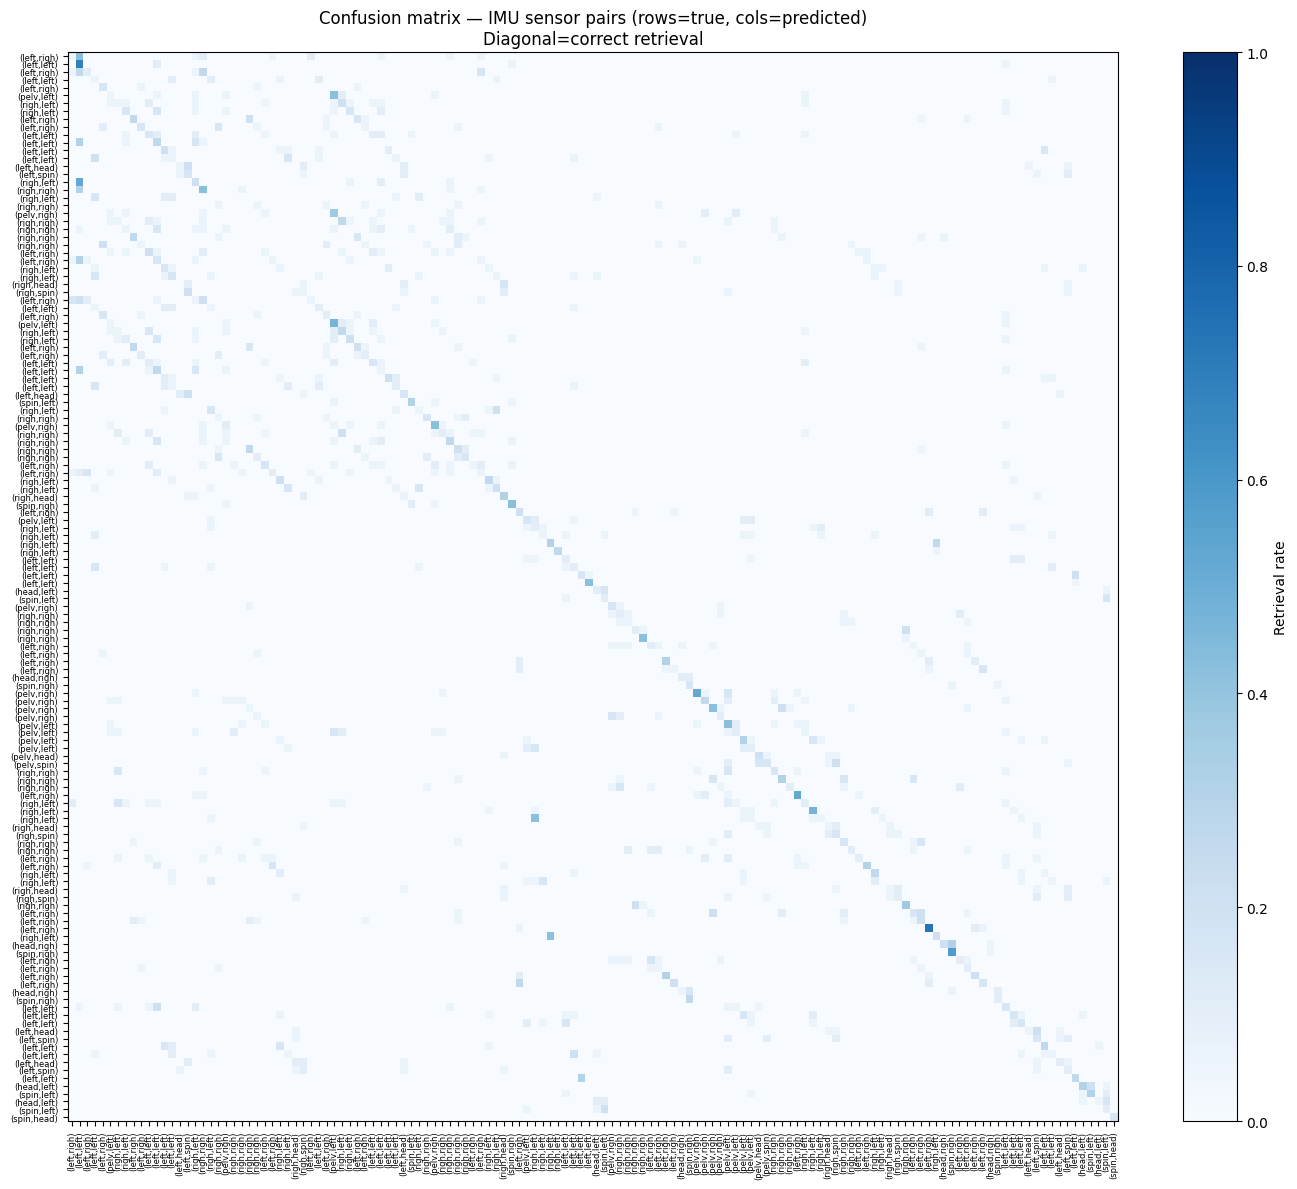

In [10]:
# Normalise confusion matrix (row = true pair, col = predicted pair)
row_sums = confusion.sum(axis=1, keepdims=True).clip(1)
conf_norm = confusion.astype(float) / row_sums

# Most common confusion pairs (excluding correct diagonal)
conf_copy = conf_norm.copy()
np.fill_diagonal(conf_copy, 0)
top_conf_flat = np.argsort(conf_copy.ravel())[::-1][:20]

print('Most frequent mis-retrieval pairs (true → predicted):')
print(f'  {"True pair":<38}  {"Predicted pair":<38}  Rate')
print('  ' + '-' * 84)
for flat_idx in top_conf_flat:
    true_idx = flat_idx // len(PAIRS)
    pred_idx = flat_idx  % len(PAIRS)
    if true_idx == pred_idx:
        continue
    ti, tj = PAIRS[true_idx]
    pi, pj = PAIRS[pred_idx]
    rate   = conf_copy[true_idx, pred_idx]
    if rate < 0.01:
        break
    true_s = f'({JOINT_NAMES[ti]}, {JOINT_NAMES[tj]})'
    pred_s = f'({JOINT_NAMES[pi]}, {JOINT_NAMES[pj]})'
    print(f'  {true_s:<38}  {pred_s:<38}  {rate*100:.1f}%')

# ── Confusion heatmap (subset: IMU sensor pairs only for readability) ─────────
sensor_pair_indices = [PAIR_TO_IDX[p] for p in sensor_pairs if p in PAIR_TO_IDX]
sensor_labels = [f'({JOINT_NAMES[i][:4]},{JOINT_NAMES[j][:4]})' for i,j in sensor_pairs if (i,j) in PAIR_TO_IDX]
sub_conf = conf_norm[np.ix_(sensor_pair_indices, sensor_pair_indices)]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sub_conf, cmap='Blues', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Retrieval rate')
ax.set_xticks(range(len(sensor_labels)))
ax.set_yticks(range(len(sensor_labels)))
ax.set_xticklabels(sensor_labels, rotation=90, fontsize=6)
ax.set_yticklabels(sensor_labels, fontsize=6)
ax.set_title('Confusion matrix — IMU sensor pairs (rows=true, cols=predicted)\nDiagonal=correct retrieval')
plt.tight_layout()
plt.show()

---
## 10 — Cosine Similarity Score Distribution

How confident is the model? Compare similarity scores at rank-1 for correct vs wrong retrievals.

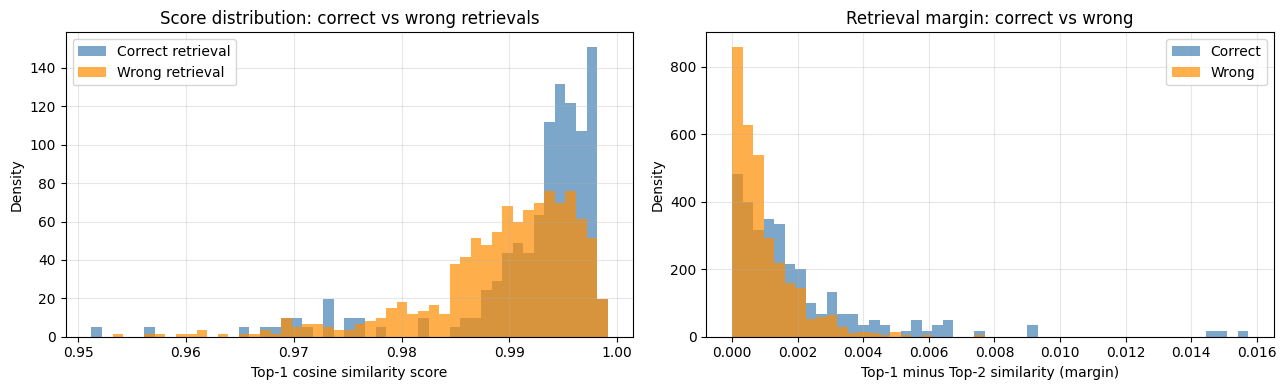

Mean similarity — correct: 0.9919  wrong: 0.9893
Mean margin     — correct: 0.0020  wrong: 0.0010


In [11]:
correct_sims, wrong_sims = [], []

# re-run a fast subset (first 3 test files) to collect score distributions
for fpath in test_files[:3]:
    data   = torch.load(fpath, map_location='cpu', weights_only=False)
    vimu   = data['vimu']['vimu_joints']
    T_seq  = vimu.shape[0]
    start  = random.randint(0, max(0, T_seq - T_WINDOW))
    window = vimu[start: start + T_WINDOW]

    with torch.no_grad():
        x_all = window.permute(1, 0, 2).to(device)
        embs  = model.encode(x_all).cpu().numpy()
        embs  = embs / (np.linalg.norm(embs, axis=-1, keepdims=True) + 1e-8)

    for true_idx, (i, j) in enumerate(PAIRS):
        e_i = torch.from_numpy(embs[i]).unsqueeze(0).to(device)
        e_j = torch.from_numpy(embs[j]).unsqueeze(0).to(device)
        with torch.no_grad():
            q_emb = model.rel_head(e_i, e_j).squeeze(0).cpu().numpy()
        q_emb = q_emb / (np.linalg.norm(q_emb) + 1e-8)

        sims     = gallery_normed @ q_emb
        ranked   = np.argsort(sims)[::-1]
        top_sim  = float(sims[ranked[0]])
        if ranked[0] == true_idx:
            correct_sims.append(top_sim)
        else:
            wrong_sims.append(top_sim)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins = np.linspace(min(min(correct_sims), min(wrong_sims)),
                   max(max(correct_sims), max(wrong_sims)), 50)
axes[0].hist(correct_sims, bins=bins, alpha=0.7, label='Correct retrieval', color='steelblue',  density=True)
axes[0].hist(wrong_sims,   bins=bins, alpha=0.7, label='Wrong retrieval',   color='darkorange', density=True)
axes[0].set_xlabel('Top-1 cosine similarity score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score distribution: correct vs wrong retrievals')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gap between top-1 and top-2 similarity (margin)
margins_correct, margins_wrong = [], []
for fpath in test_files[:3]:
    data   = torch.load(fpath, map_location='cpu', weights_only=False)
    vimu   = data['vimu']['vimu_joints']
    T_seq  = vimu.shape[0]
    start  = random.randint(0, max(0, T_seq - T_WINDOW))
    window = vimu[start: start + T_WINDOW]

    with torch.no_grad():
        x_all = window.permute(1, 0, 2).to(device)
        embs  = model.encode(x_all).cpu().numpy()
        embs  = embs / (np.linalg.norm(embs, axis=-1, keepdims=True) + 1e-8)

    for true_idx, (i, j) in enumerate(PAIRS):
        e_i = torch.from_numpy(embs[i]).unsqueeze(0).to(device)
        e_j = torch.from_numpy(embs[j]).unsqueeze(0).to(device)
        with torch.no_grad():
            q_emb = model.rel_head(e_i, e_j).squeeze(0).cpu().numpy()
        q_emb = q_emb / (np.linalg.norm(q_emb) + 1e-8)
        sims   = gallery_normed @ q_emb
        ranked = np.argsort(sims)[::-1]
        margin = float(sims[ranked[0]] - sims[ranked[1]])
        if ranked[0] == true_idx:
            margins_correct.append(margin)
        else:
            margins_wrong.append(margin)

bins2 = np.linspace(0, max(max(margins_correct), max(margins_wrong)), 50)
axes[1].hist(margins_correct, bins=bins2, alpha=0.7, label='Correct', color='steelblue',  density=True)
axes[1].hist(margins_wrong,   bins=bins2, alpha=0.7, label='Wrong',   color='darkorange', density=True)
axes[1].set_xlabel('Top-1 minus Top-2 similarity (margin)')
axes[1].set_ylabel('Density')
axes[1].set_title('Retrieval margin: correct vs wrong')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mean similarity — correct: {np.mean(correct_sims):.4f}  wrong: {np.mean(wrong_sims):.4f}')
print(f'Mean margin     — correct: {np.mean(margins_correct):.4f}  wrong: {np.mean(margins_wrong):.4f}')

---
## 11 — Summary

In [12]:
print('=' * 60)
print('RETRIEVAL EVALUATION SUMMARY')
print('=' * 60)
print(f'Checkpoint    : epoch {ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.5f}')
print(f'Gallery       : {wf_count} train files  →  {len(PAIRS)} pair embeddings')
print(f'Test queries  : {len(test_files)} files  ×  {len(PAIRS)} pairs = {n_queries} total')
print()
print('All-pairs retrieval (276 classes):')
print(f'  Top-1  : {global_hits["top1"]/n_queries*100:.2f}%   (chance: {1/len(PAIRS)*100:.2f}%)')
print(f'  Top-5  : {global_hits["top5"]/n_queries*100:.2f}%   (chance: {5/len(PAIRS)*100:.2f}%)')
print(f'  Top-10 : {global_hits["top10"]/n_queries*100:.2f}%   (chance: {10/len(PAIRS)*100:.2f}%)')
print(f'  MRR    : {np.mean(all_rr):.4f}')
print()
print(f'IMU sensor pairs only ({len(sensor_pairs)} pairs):')
print(f'  Top-1  : {imu_hits["top1"]/imu_n*100:.2f}%')
print(f'  Top-5  : {imu_hits["top5"]/imu_n*100:.2f}%')
print(f'  Top-10 : {imu_hits["top10"]/imu_n*100:.2f}%')
print(f'  MRR    : {np.mean(imu_rr):.4f}')
print()
print(f'Adjacent pairs    mean top-1 : {np.mean(adj_accs)*100:.2f}%')
print(f'Non-adjacent pairs mean top-1: {np.mean(nadj_accs)*100:.2f}%')

RETRIEVAL EVALUATION SUMMARY
Checkpoint    : epoch 22  val_loss=4.19302
Gallery       : 885 train files  →  276 pair embeddings
Test queries  : 19 files  ×  276 pairs = 5244 total

All-pairs retrieval (276 classes):
  Top-1  : 21.80%   (chance: 0.36%)
  Top-5  : 59.59%   (chance: 1.81%)
  Top-10 : 76.37%   (chance: 3.62%)
  MRR    : 0.3888

IMU sensor pairs only (136 pairs):
  Top-1  : 16.72%
  Top-5  : 49.38%
  Top-10 : 66.64%
  MRR    : 0.3195

Adjacent pairs    mean top-1 : 40.05%
Non-adjacent pairs mean top-1: 20.14%


---
## 12 — 3-Sensor Setup

Given **3 unknown IMU sensors**, can the model identify which 3 body joints they belong to?

**Approach:**

1. For each test window, compute pairwise relationship embeddings for all C(17,2)=136 IMU sensor pairs using the trained model.
2. Enumerate all C(17,3)=680 possible 3-sensor configurations from the 17 real IMU joints.
3. For each query triplet (true sensors *a, b, c*), score every candidate configuration by summing the 3 cosine similarities of its gallery pair vectors against the 3 query pair embeddings — optimising over all 6 sensor-to-joint assignment permutations.
4. Rank all 680 candidate configs by score. The true config should rank first.

Metrics: **Top-1 / Top-5 / Top-10 accuracy** and **MRR** across all test files and all C(17,3) query triplets.

In [13]:
from itertools import combinations, permutations as iterperms

N_IMU        = len(IMU_JOINTS)                      # 17
imu_triplets = list(combinations(range(N_IMU), 3))  # C(17,3) = 680
N_TRIPLETS   = len(imu_triplets)
print(f'3-sensor combinations : {N_TRIPLETS}')

# ── Gallery vectors for every candidate triplet ────────────────────────────
# gal_triplets[t, k] = normed gallery embedding for the k-th pair of triplet t
# pair order: k=0 ↔ (a,b), k=1 ↔ (a,c), k=2 ↔ (b,c)
gal_triplets = np.zeros((N_TRIPLETS, 3, d_embed), dtype=np.float32)
for t_idx, (a, b, c) in enumerate(imu_triplets):
    ja, jb, jc = IMU_JOINTS[a], IMU_JOINTS[b], IMU_JOINTS[c]
    for k, (ji, jj) in enumerate([(ja, jb), (ja, jc), (jb, jc)]):
        gal_triplets[t_idx, k] = gallery_normed[PAIR_TO_IDX[tuple(sorted([ji, jj]))]]

print(f'Gallery triplets      : {gal_triplets.shape}')

# ── Permutation → gallery-index mapping ───────────────────────────────────
# Permutation p = (p0, p1, p2): sensor_a→joint_p0, sensor_b→joint_p1, sensor_c→joint_p2
# Query pairs (a,b)=q[0], (a,c)=q[1], (b,c)=q[2]
# Gallery pairs (0,1)=g[0], (0,2)=g[1], (1,2)=g[2]  (joint indices within triplet)
# Under permutation p, query pair (a,b) maps to gallery pair sorted(p0,p1).
_P3 = {(0,1): 0, (0,2): 1, (1,2): 2}
PERM_GIDX = np.array([
    [_P3[tuple(sorted([p[sa], p[sb]]))] for (sa, sb) in [(0,1),(0,2),(1,2)]]
    for p in iterperms([0, 1, 2])
], dtype=np.int32)   # [6, 3]

print(f'Permutation-to-gallery-index table (6 perms × 3 query pairs):\n{PERM_GIDX}')

# Quick sanity: identity permutation (0,1,2) should give [0,1,2]
assert list(PERM_GIDX[0]) == [0, 1, 2], 'Identity permutation mapping is wrong'

3-sensor combinations : 680
Gallery triplets      : (680, 3, 64)
Permutation-to-gallery-index table (6 perms × 3 query pairs):
[[0 1 2]
 [1 0 2]
 [0 2 1]
 [2 0 1]
 [1 2 0]
 [2 1 0]]


In [14]:
# ── Vectorised 3-sensor evaluation ────────────────────────────────────────
# Per test file:
#   1. Encode all 17 IMU joints; run rel_head for all 136 pairs → pair_emb_mat [17,17,d]
#   2. Stack query embeddings for all 680 triplets → q_all [680, 3, d]
#   3. Compute sims [680, 680, 3, 3] in one einsum (all query × candidate × pair combos)
#   4. Score all 6 sensor-to-joint assignment permutations, take max → config_scores [680, 680]
#   5. Rank each query's true config; collect metrics

hits_3s       = {'top1': 0, 'top5': 0, 'top10': 0}
rr_3s         = []
triplet_ranks = []   # true rank for every (file × triplet) query

for fpath in tqdm(test_files, desc='3-sensor evaluation'):
    data   = torch.load(fpath, map_location='cpu', weights_only=False)
    vimu   = data['vimu']['vimu_joints']
    T_seq  = vimu.shape[0]
    start  = random.randint(0, max(0, T_seq - T_WINDOW))
    window = vimu[start: start + T_WINDOW]          # [300, 24, 9]

    with torch.no_grad():
        # Encode all 24 joints, keep the 17 IMU ones
        x_all    = window.permute(1, 0, 2).to(device)   # [24, T, 9]
        all_embs = model.encode(x_all)                   # [24, d_embed]
        all_embs = F.normalize(all_embs, dim=-1)
        imu_embs = all_embs[IMU_JOINTS]                  # [17, d_embed]

        # Compute all 136 pairwise relationship embeddings → [17, 17, d_embed]
        pair_emb_mat = torch.zeros(N_IMU, N_IMU, d_embed, device=device)
        for a in range(N_IMU):
            for b in range(a + 1, N_IMU):
                rel = model.rel_head(
                    imu_embs[a].unsqueeze(0),
                    imu_embs[b].unsqueeze(0),
                ).squeeze(0)
                rel = F.normalize(rel, dim=-1)
                pair_emb_mat[a, b] = rel
                pair_emb_mat[b, a] = rel   # symmetric

    pair_np = pair_emb_mat.cpu().numpy()   # [17, 17, d_embed]

    # Stack query embeddings for all 680 triplets: [680, 3, d_embed]
    # axis 1 order: pair (a,b)=0, (a,c)=1, (b,c)=2
    q_all = np.stack([
        np.stack([pair_np[a, b], pair_np[a, c], pair_np[b, c]])
        for a, b, c in imu_triplets
    ])   # [680, 3, d_embed]

    # sims[t, c, q, n] = q_all[t, q] · gal_triplets[c, n]
    # → [N_TRIPLETS, N_TRIPLETS, 3, 3]
    sims = np.einsum('tqd,cnd->tcqn', q_all, gal_triplets)

    # Score every permutation for every (query, candidate) pair
    # perm_scores[t, c, p] = sum over q of sims[t, c, q, PERM_GIDX[p, q]]
    perm_scores = np.zeros((N_TRIPLETS, N_TRIPLETS, 6), dtype=np.float32)
    for p_idx, gidx_row in enumerate(PERM_GIDX):   # gidx_row: [3]
        perm_scores[:, :, p_idx] = (
            sims[:, :, 0, gidx_row[0]] +
            sims[:, :, 1, gidx_row[1]] +
            sims[:, :, 2, gidx_row[2]]
        )

    config_scores = perm_scores.max(axis=2)         # [680, 680] best-perm score

    # Rank all candidates for each query (descending)
    ranked_cands = np.argsort(-config_scores, axis=1)   # [680, 680]
    true_ranks   = np.array([
        int(np.where(ranked_cands[t] == t)[0][0]) + 1
        for t in range(N_TRIPLETS)
    ])   # [680]  —  rank of the true config for each query triplet

    hits_3s['top1']  += int((true_ranks == 1).sum())
    hits_3s['top5']  += int((true_ranks <= 5).sum())
    hits_3s['top10'] += int((true_ranks <= 10).sum())
    rr_3s.extend((1.0 / true_ranks).tolist())
    triplet_ranks.extend(true_ranks.tolist())

n_3s = len(triplet_ranks)
print(f'\n3-Sensor Configuration Identification  ({N_TRIPLETS} candidate configs)')
print(f'Total queries   : {n_3s}  ({len(test_files)} files × {N_TRIPLETS} triplets)')
print(f'Top-1  accuracy : {hits_3s["top1"]/n_3s*100:.2f}%')
print(f'Top-5  accuracy : {hits_3s["top5"]/n_3s*100:.2f}%')
print(f'Top-10 accuracy : {hits_3s["top10"]/n_3s*100:.2f}%')
print(f'MRR             : {np.mean(rr_3s):.4f}')
print(f'Chance baseline : top-1 = {1/N_TRIPLETS*100:.3f}%  top-5 = {5/N_TRIPLETS*100:.2f}%')

3-sensor evaluation: 100%|██████████| 19/19 [00:02<00:00,  7.62it/s]


3-Sensor Configuration Identification  (680 candidate configs)
Total queries   : 12920  (19 files × 680 triplets)
Top-1  accuracy : 7.55%
Top-5  accuracy : 24.13%
Top-10 accuracy : 35.12%
MRR             : 0.1659
Chance baseline : top-1 = 0.147%  top-5 = 0.74%


Top-10 most identifiable 3-sensor configurations:
  Triplet (sensor names)                                   Top-1 acc
  --------------------------------------------------------------------
  (left_wrist, left_shoulder, left_elbow)                  94.7%
  (right_wrist, right_shoulder, right_elbow)               89.5%
  (right_shoulder, head, spine3)                           84.2%
  (left_ankle, head, spine3)                               73.7%
  (left_wrist, right_elbow, left_elbow)                    68.4%
  (pelvis, head, spine3)                                   57.9%
  (right_foot, right_shoulder, head)                       57.9%
  (left_ankle, left_foot, head)                            52.6%
  (left_ankle, left_foot, left_knee)                       52.6%
  (left_ankle, left_foot, right_shoulder)                  52.6%

Top-10 least identifiable 3-sensor configurations:
  Triplet (sensor names)                                   Top-1 acc
  -------------------------------------

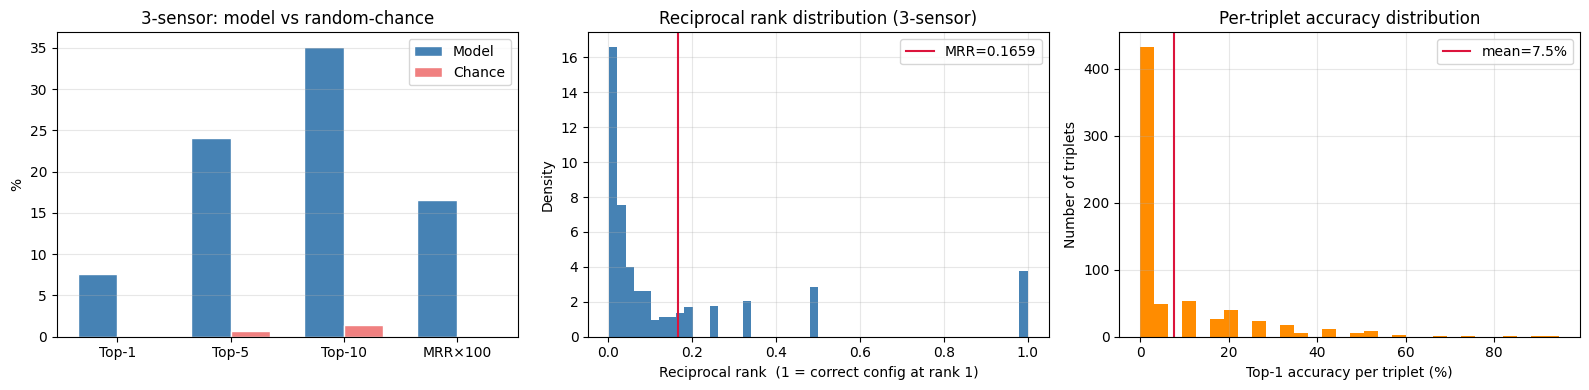


Summary vs 2-sensor baseline:
  2-sensor (IMU pairs) top-1 : 16.72%  (136 classes)
  3-sensor config      top-1 : 7.55%  (680 classes)


In [15]:
# ── Per-triplet accuracy (averaged across all test files) ─────────────────
triplet_ranks_arr = np.array(triplet_ranks).reshape(len(test_files), N_TRIPLETS)
per_triplet_top1  = (triplet_ranks_arr == 1).mean(axis=0)   # [680]

best_idx  = np.argsort(-per_triplet_top1)
worst_idx = np.argsort(per_triplet_top1)

TOP_N = 10
print(f'Top-{TOP_N} most identifiable 3-sensor configurations:')
print(f'  {"Triplet (sensor names)":<55}  Top-1 acc')
print('  ' + '-' * 68)
for idx in best_idx[:TOP_N]:
    a, b, c = imu_triplets[idx]
    names   = f'({IMU_NAMES[a]}, {IMU_NAMES[b]}, {IMU_NAMES[c]})'
    print(f'  {names:<55}  {per_triplet_top1[idx]*100:.1f}%')

print()
print(f'Top-{TOP_N} least identifiable 3-sensor configurations:')
print(f'  {"Triplet (sensor names)":<55}  Top-1 acc')
print('  ' + '-' * 68)
for idx in worst_idx[:TOP_N]:
    a, b, c = imu_triplets[idx]
    names   = f'({IMU_NAMES[a]}, {IMU_NAMES[b]}, {IMU_NAMES[c]})'
    print(f'  {names:<55}  {per_triplet_top1[idx]*100:.1f}%')

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar: model vs chance
labels_3s  = ['Top-1', 'Top-5', 'Top-10', 'MRR×100']
model_3s   = [hits_3s['top1']/n_3s*100, hits_3s['top5']/n_3s*100,
              hits_3s['top10']/n_3s*100, np.mean(rr_3s)*100]
chance_3s  = [1/N_TRIPLETS*100, 5/N_TRIPLETS*100,
              10/N_TRIPLETS*100, 1/N_TRIPLETS*100]
x = np.arange(len(labels_3s))
w = 0.35
axes[0].bar(x - w/2, model_3s,  w, label='Model',  color='steelblue',  edgecolor='white')
axes[0].bar(x + w/2, chance_3s, w, label='Chance', color='lightcoral', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_3s)
axes[0].set_ylabel('%')
axes[0].set_title('3-sensor: model vs random-chance')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# RR distribution
axes[1].hist(rr_3s, bins=50, color='steelblue', edgecolor='none', density=True)
axes[1].axvline(np.mean(rr_3s), color='crimson', lw=1.5, label=f'MRR={np.mean(rr_3s):.4f}')
axes[1].set_xlabel('Reciprocal rank  (1 = correct config at rank 1)')
axes[1].set_ylabel('Density')
axes[1].set_title('Reciprocal rank distribution (3-sensor)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Per-triplet top-1 accuracy histogram
axes[2].hist(per_triplet_top1 * 100, bins=30, color='darkorange', edgecolor='none')
axes[2].axvline(per_triplet_top1.mean() * 100, color='crimson', lw=1.5,
                label=f'mean={per_triplet_top1.mean()*100:.1f}%')
axes[2].set_xlabel('Top-1 accuracy per triplet (%)')
axes[2].set_ylabel('Number of triplets')
axes[2].set_title('Per-triplet accuracy distribution')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nSummary vs 2-sensor baseline:')
print(f'  2-sensor (IMU pairs) top-1 : {imu_hits["top1"]/imu_n*100:.2f}%  ({len(sensor_pairs)} classes)')
print(f'  3-sensor config      top-1 : {hits_3s["top1"]/n_3s*100:.2f}%  ({N_TRIPLETS} classes)')

---
## 13 — N-Sensor Generalisation

Given **N unknown IMU sensors**, identify which N body joints they correspond to by scoring all C(17,N) candidate configurations.

**Scoring** (per candidate):
- Compute all C(N,2) pairwise relationship embeddings for the N query sensors.
- For each candidate config, try all N! sensor→joint assignment permutations and take the maximum sum of cosine similarities.

**Complexity note:**
- C(17,N) configurations and N! permutations grow fast — for N=6 (12 376 configs, 720 perms) and N=7 (19 448 configs, 5040 perms) we evaluate a random sample of query configs per file to keep runtime feasible. Accuracy is therefore a statistical estimate for large N.

In [32]:
from itertools import combinations, permutations as iterperms
from math import comb, factorial

# ── Runtime budget: cap sampled query configs for large N ─────────────────
# None = evaluate all configs; an int = randomly sample that many per file
# MAX_QUERY_CONFIGS = {3: None, 4: None, 5: None, 6: 1000, 7: 500}
MAX_QUERY_CONFIGS = {2:None, 3: None, 4: None, 5: None}

# ── N to evaluate ─────────────────────────────────────────────────────────
# N_VALUES = [3, 4, 5, 6, 7]
N_VALUES = [2, 3, 4, 5]

for N in N_VALUES:
    n_cfg = comb(N_IMU, N)
    n_perm = factorial(N)
    n_pairs_N = comb(N, 2)
    q_cap = MAX_QUERY_CONFIGS[N]
    print(f'N={N}: C(17,{N})={n_cfg:>6} configs  '
          f'C({N},2)={n_pairs_N} pairs  '
          f'{N}!={n_perm:>4} perms  '
          f'query cap={q_cap}')


def compute_pair_emb_mat(window):
    """Encode one 300-frame window → [17, 17, d_embed] rel-head embeddings."""
    with torch.no_grad():
        x_all    = window.permute(1, 0, 2).to(device)        # [24, T, 9]
        all_embs = F.normalize(model.encode(x_all), dim=-1)  # [24, d_embed]
        imu_embs = all_embs[IMU_JOINTS]                       # [17, d_embed]

        mat = torch.zeros(N_IMU, N_IMU, d_embed, device=device)
        for a in range(N_IMU):
            for b in range(a + 1, N_IMU):
                rel = F.normalize(
                    model.rel_head(imu_embs[a].unsqueeze(0),
                                   imu_embs[b].unsqueeze(0)).squeeze(0), dim=-1)
                mat[a, b] = rel
                mat[b, a] = rel
    return mat.cpu().numpy()   # [17, 17, d_embed]


def evaluate_n_sensors(N, max_query=None, seed=42):
    """
    Identify which N of the 17 IMU joints a set of N unknown sensors belongs to.

    Parameters
    ----------
    N          : number of sensors
    max_query  : if set, randomly sample this many query configs per test file
                 (gives a statistical estimate instead of exhaustive evaluation)
    seed       : RNG seed for reproducible sampling
    """
    rng = np.random.default_rng(seed)

    configs   = list(combinations(range(N_IMU), N))    # all C(17,N) sensor-index combos
    n_configs = len(configs)
    pair_list = list(combinations(range(N), 2))        # C(N,2) within-config pairs
    n_pairs   = len(pair_list)
    all_perms = list(iterperms(range(N)))               # all N! permutations
    n_perms   = len(all_perms)
    pair_to_k = {p: i for i, p in enumerate(pair_list)}

    # perm_gidx[p, k] = gallery pair index that query pair k maps to under permutation p
    perm_gidx = np.array([
        [pair_to_k[tuple(sorted([perm[a], perm[b]]))] for a, b in pair_list]
        for perm in all_perms
    ], dtype=np.int32)   # [n_perms, n_pairs]

    # Precompute gallery embeddings for all C(17,N) candidate configs [n_configs, n_pairs, d_embed]
    gal_configs = np.zeros((n_configs, n_pairs, d_embed), dtype=np.float32)
    for c_idx, cfg in enumerate(configs):
        joints = [IMU_JOINTS[s] for s in cfg]
        for k, (a, b) in enumerate(pair_list):
            key = tuple(sorted([joints[a], joints[b]]))
            gal_configs[c_idx, k] = gallery_normed[PAIR_TO_IDX[key]]

    # Flat view for BLAS-accelerated matmul  [n_configs*n_pairs, d_embed]
    gal_flat = gal_configs.reshape(n_configs * n_pairs, d_embed)

    hits    = {'top1': 0, 'top5': 0, 'top10': 0}
    rr_list = []
    q_range = np.arange(n_pairs)

    for fpath in tqdm(test_files, desc=f'N={N} ({n_configs} configs, {n_perms} perms)'):
        data   = torch.load(fpath, map_location='cpu', weights_only=False)
        vimu   = data['vimu']['vimu_joints']
        start  = random.randint(0, max(0, vimu.shape[0] - T_WINDOW))
        window = vimu[start: start + T_WINDOW]

        pair_np = compute_pair_emb_mat(window)   # [17, 17, d_embed]

        # Which query configs to evaluate this file
        if max_query is not None and max_query < n_configs:
            query_idxs = rng.choice(n_configs, size=max_query, replace=False)
        else:
            query_idxs = range(n_configs)

        for true_idx in query_idxs:
            cfg = configs[true_idx]

            # Query pair embeddings [n_pairs, d_embed]
            q_pairs = np.stack([pair_np[cfg[a], cfg[b]] for a, b in pair_list])

            # Similarity between every query pair and every gallery pair (BLAS matmul)
            # q_pairs @ gal_flat.T = [n_pairs, n_configs*n_pairs]
            sims_flat  = q_pairs @ gal_flat.T                                    # [n_pairs, n_configs*n_pairs]
            sim_matrix = sims_flat.reshape(n_pairs, n_configs, n_pairs).transpose(1, 0, 2)  # [n_configs, n_pairs, n_pairs]

            # Best-permutation score for each candidate config
            config_scores = np.full(n_configs, -np.inf, dtype=np.float32)
            for p_idx in range(n_perms):
                scores_p = sim_matrix[:, q_range, perm_gidx[p_idx]].sum(axis=1)
                np.maximum(config_scores, scores_p, out=config_scores)

            ranked = np.argsort(-config_scores)
            rank   = int(np.where(ranked == true_idx)[0][0]) + 1

            hits['top1']  += (rank == 1)
            hits['top5']  += (rank <= 5)
            hits['top10'] += (rank <= 10)
            rr_list.append(1.0 / rank)

    n_q = len(rr_list)
    sampled = max_query is not None and max_query < n_configs
    return dict(
        N=N, n_configs=n_configs, n_pairs=n_pairs, n_perms=n_perms,
        n_queries=n_q, sampled=sampled,
        top1=hits['top1'] / n_q * 100,
        top5=hits['top5'] / n_q * 100,
        top10=hits['top10'] / n_q * 100,
        mrr=float(np.mean(rr_list)),
        chance_top1=100.0 / n_configs,
        chance_top5=500.0 / n_configs,
    )

N=2: C(17,2)=   136 configs  C(2,2)=1 pairs  2!=   2 perms  query cap=None
N=3: C(17,3)=   680 configs  C(3,2)=3 pairs  3!=   6 perms  query cap=None
N=4: C(17,4)=  2380 configs  C(4,2)=6 pairs  4!=  24 perms  query cap=None
N=5: C(17,5)=  6188 configs  C(5,2)=10 pairs  5!= 120 perms  query cap=None


In [33]:
# ── Run evaluation for N = 3, 4, 5, 6, 7 ─────────────────────────────────
all_results = {}

for N in N_VALUES:
    res = evaluate_n_sensors(N, max_query=MAX_QUERY_CONFIGS[N])
    all_results[N] = res

    sampled_note = f'  (sampled {MAX_QUERY_CONFIGS[N]} query configs/file)' if res['sampled'] else ''
    print(f"\nN={N}  [{res['n_configs']} configs | {res['n_perms']} perms | {res['n_queries']} total queries{sampled_note}]")
    print(f"  Top-1  : {res['top1']:6.2f}%   (chance {res['chance_top1']:.3f}%)")
    print(f"  Top-5  : {res['top5']:6.2f}%   (chance {res['chance_top5']:.2f}%)")
    print(f"  Top-10 : {res['top10']:6.2f}%")
    print(f"  MRR    : {res['mrr']:.4f}")

N=2 (136 configs, 2 perms): 100%|██████████| 19/19 [00:00<00:00, 29.09it/s]



N=2  [136 configs | 2 perms | 2584 total queries]
  Top-1  :  14.86%   (chance 0.735%)
  Top-5  :  43.15%   (chance 3.68%)
  Top-10 :  57.24%
  MRR    : 0.2860


N=3 (680 configs, 6 perms): 100%|██████████| 19/19 [00:04<00:00,  4.33it/s]



N=3  [680 configs | 6 perms | 12920 total queries]
  Top-1  :   8.00%   (chance 0.147%)
  Top-5  :  25.17%   (chance 0.74%)
  Top-10 :  37.00%
  MRR    : 0.1736


N=4 (2380 configs, 24 perms): 100%|██████████| 19/19 [00:38<00:00,  2.03s/it]



N=4  [2380 configs | 24 perms | 45220 total queries]
  Top-1  :   3.86%   (chance 0.042%)
  Top-5  :  12.35%   (chance 0.21%)
  Top-10 :  19.14%
  MRR    : 0.0918


N=5 (6188 configs, 120 perms): 100%|██████████| 19/19 [14:55<00:00, 47.14s/it]


N=5  [6188 configs | 120 perms | 117572 total queries]
  Top-1  :   1.75%   (chance 0.016%)
  Top-5  :   6.60%   (chance 0.08%)
  Top-10 :  11.07%
  MRR    : 0.0514


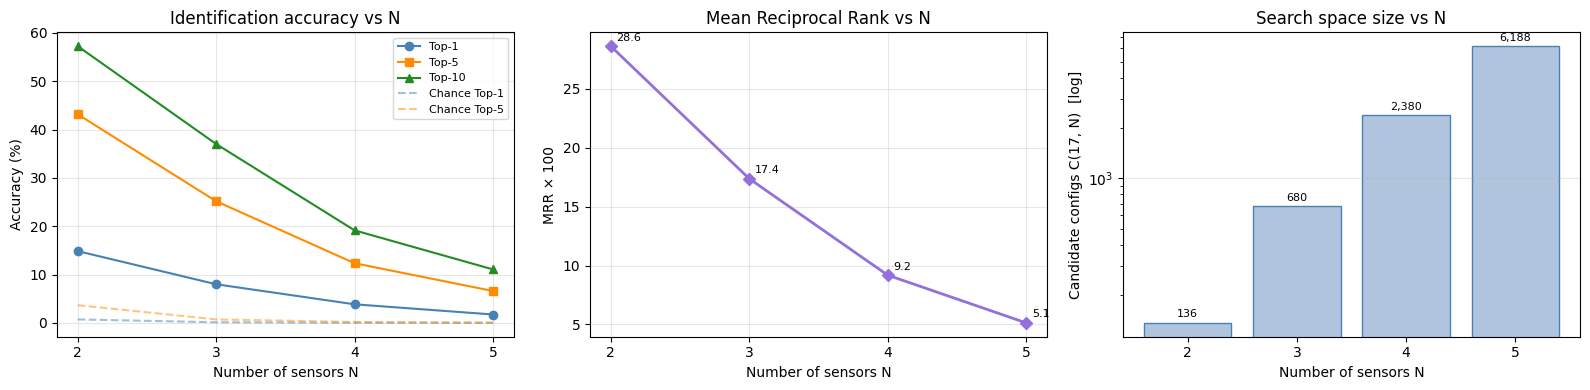


  N   Configs   Perms   Top-1%   Chance%    Lift   Top-5%     MRR  Sampled?
---------------------------------------------------------------------------
  2       136       2    14.86     0.735    20.2x    43.15  0.2860  no
  3       680       6     8.00     0.147    54.4x    25.17  0.1736  no
  4     2,380      24     3.86     0.042    91.8x    12.35  0.0918  no
  5     6,188     120     1.75     0.016   108.3x     6.60  0.0514  no


In [34]:
# ── Comparison plot: accuracy vs N ────────────────────────────────────────
Ns          = N_VALUES
top1s       = [all_results[N]['top1']       for N in Ns]
top5s       = [all_results[N]['top5']       for N in Ns]
top10s      = [all_results[N]['top10']      for N in Ns]
mrrs        = [all_results[N]['mrr'] * 100  for N in Ns]
chance_top1 = [all_results[N]['chance_top1'] for N in Ns]
chance_top5 = [all_results[N]['chance_top5'] for N in Ns]
n_configs   = [all_results[N]['n_configs']  for N in Ns]
sampled     = [all_results[N]['sampled']    for N in Ns]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Accuracy curves ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(Ns, top1s,  'o-', color='steelblue',   label='Top-1')
ax.plot(Ns, top5s,  's-', color='darkorange',   label='Top-5')
ax.plot(Ns, top10s, '^-', color='forestgreen',  label='Top-10')
ax.plot(Ns, chance_top1, '--', color='steelblue',  alpha=0.5, label='Chance Top-1')
ax.plot(Ns, chance_top5, '--', color='darkorange',  alpha=0.5, label='Chance Top-5')
for i, (n, s) in enumerate(zip(Ns, sampled)):
    if s:
        ax.annotate('~sampled', (n, top1s[i]), textcoords='offset points',
                    xytext=(4, 4), fontsize=7, color='grey')
ax.set_xlabel('Number of sensors N')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Identification accuracy vs N')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xticks(Ns)

# ── MRR curve ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(Ns, mrrs, 'D-', color='mediumpurple', lw=2)
for n, m in zip(Ns, mrrs):
    ax.annotate(f'{m:.1f}', (n, m), textcoords='offset points',
                xytext=(4, 4), fontsize=8)
ax.set_xlabel('Number of sensors N')
ax.set_ylabel('MRR × 100')
ax.set_title('Mean Reciprocal Rank vs N')
ax.grid(alpha=0.3); ax.set_xticks(Ns)

# ── Number of candidate configs (log scale) ────────────────────────────────
ax = axes[2]
ax.bar(Ns, n_configs, color='lightsteelblue', edgecolor='steelblue')
for n, c in zip(Ns, n_configs):
    ax.text(n, c * 1.05, f'{c:,}', ha='center', va='bottom', fontsize=8)
ax.set_yscale('log')
ax.set_xlabel('Number of sensors N')
ax.set_ylabel('Candidate configs C(17, N)  [log]')
ax.set_title('Search space size vs N')
ax.grid(axis='y', alpha=0.3); ax.set_xticks(Ns)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print(f'\n{"N":>3}  {"Configs":>8}  {"Perms":>6}  {"Top-1%":>7}  '
      f'{"Chance%":>8}  {"Lift":>6}  {"Top-5%":>7}  {"MRR":>6}  Sampled?')
print('-' * 75)
for N in Ns:
    r = all_results[N]
    lift = r['top1'] / r['chance_top1']
    s    = 'yes' if r['sampled'] else 'no'
    print(f'{N:>3}  {r["n_configs"]:>8,}  {r["n_perms"]:>6,}  '
          f'{r["top1"]:>7.2f}  {r["chance_top1"]:>8.3f}  '
          f'{lift:>6.1f}x  {r["top5"]:>7.2f}  {r["mrr"]:>6.4f}  {s}')

---
## 14 — Original Lookup Table — Handcrafted Features

Compares the learned model against the **original feature-engineering approach** from `notebooks/lookup_table_analysis.ipynb`.

That notebook computes a **6-dimensional relationship vector** per joint pair per training sequence and averages over all 885 files:

| # | Feature | Signal | Description |
|---|---------|--------|-------------|
| 0 | `cross_corr_peak` | accel ch 6-8 | peak of normalised cross-correlation |
| 1 | `cross_corr_lag` | accel ch 6-8 | lag at peak, normalised by T |
| 2 | `magnitude_ratio` | accel ch 6-8 | log(RMS_i / RMS_j), clipped to [−5, 5] |
| 3 | `dtw_distance` | accel ch 6-8 | DTW (30-pt downsample), normalised by T |
| 4 | `orientation_similarity` | orient ch 0-5 | mean cosine similarity over time |
| 5 | `relative_orientation_std` | orient ch 0-5 | std of cosine similarity over time |

Gallery features are **min-max normalised to [0, 1]** per dimension using the training-data range.
Query features at test time are normalised with the same training parameters.
Retrieval similarity: **negative L² distance** in the normalised 6-D space (closer = more similar).

In [35]:
from scipy.signal import correlate as sp_correlate

HC_TABLE_DIR = Path('../notebooks')
HC_N_FEAT    = 6

# ── Load the pre-built normalised gallery [24, 24, 6] ─────────────────────
hc_table_norm = torch.load(
    HC_TABLE_DIR / 'lookup_table_mean_normalized.pt',
    map_location='cpu', weights_only=False
).numpy().astype(np.float32)   # [24, 24, 6]

# ── Recover the per-feature normalization params from the raw table ────────
# (needed to normalize query features the same way at test time)
hc_table_raw = torch.load(
    HC_TABLE_DIR / 'lookup_table_mean.pt',
    map_location='cpu', weights_only=False
).numpy().astype(np.float32)   # [24, 24, 6]

# replicate the same pre-processing from the notebook:
# clip feature 2 (magnitude_ratio) to [-5, 5], then min-max per feature
hc_raw_clipped = hc_table_raw.copy()
hc_raw_clipped[:, :, 2] = np.clip(hc_raw_clipped[:, :, 2], -5.0, 5.0)
hc_feat_min   = hc_raw_clipped.min(axis=(0, 1))   # [6]
hc_feat_range = hc_raw_clipped.max(axis=(0, 1)) - hc_feat_min + 1e-8   # [6]

# Pre-flatten gallery for 276 unique pairs  [276, 6]
hc_gallery = np.stack([hc_table_norm[i, j] for i, j in PAIRS])   # [276, 6]

print(f'Handcrafted gallery shape : {hc_gallery.shape}')
print(f'Feature names : cross_corr_peak, cross_corr_lag, magnitude_ratio, '
      f'dtw_distance, orientation_similarity, relative_orientation_std')
print(f'Normalization  : min={hc_feat_min.round(4)}')
print(f'               : range={hc_feat_range.round(4)}')


# ── Lightweight DTW (no external dep, same as in lookup_table notebook) ────
def _dtw(a: np.ndarray, b: np.ndarray) -> float:
    n, m = len(a), len(b)
    cost = np.full((n, m), np.inf)
    cost[0, 0] = abs(a[0] - b[0])
    for i in range(1, n):  cost[i, 0] = cost[i-1, 0] + abs(a[i] - b[0])
    for j in range(1, m):  cost[0, j] = cost[0, j-1] + abs(a[0] - b[j])
    for i in range(1, n):
        for j in range(1, m):
            cost[i, j] = abs(a[i] - b[j]) + min(cost[i-1,j], cost[i,j-1], cost[i-1,j-1])
    return float(cost[-1, -1])


def compute_hc_features(vimu_np: np.ndarray, i: int, j: int) -> np.ndarray:
    """
    vimu_np : [T, 24, 9]  (numpy, same layout as vimu_joints)
    Returns normalised 6-D feature vector for joint pair (i, j).
    """
    T = vimu_np.shape[0]
    acc_i = np.linalg.norm(vimu_np[:, i, 6:9], axis=-1)
    acc_j = np.linalg.norm(vimu_np[:, j, 6:9], axis=-1)

    xcorr   = sp_correlate(acc_i - acc_i.mean(), acc_j - acc_j.mean(), mode='full')
    lags    = np.arange(-(T - 1), T)
    pk_idx  = int(np.argmax(np.abs(xcorr)))
    denom   = acc_i.std() * acc_j.std() * T + 1e-8
    cc_peak = float(xcorr[pk_idx] / denom)
    cc_lag  = float(lags[pk_idx] / T)

    rms_i  = float(np.sqrt(np.mean(acc_i**2))) + 1e-8
    rms_j  = float(np.sqrt(np.mean(acc_j**2))) + 1e-8
    mag_ratio = float(np.log(rms_i / rms_j))

    step = max(T // 30, 1)
    dtw_d = _dtw(acc_i[::step], acc_j[::step]) / T

    ori_i = vimu_np[:, i, 0:6]
    ori_j = vimu_np[:, j, 0:6]
    ori_i_n = ori_i / (np.linalg.norm(ori_i, axis=-1, keepdims=True) + 1e-8)
    ori_j_n = ori_j / (np.linalg.norm(ori_j, axis=-1, keepdims=True) + 1e-8)
    dots    = np.sum(ori_i_n * ori_j_n, axis=-1)

    raw = np.array([cc_peak, cc_lag, np.clip(mag_ratio, -5.0, 5.0),
                    dtw_d, float(dots.mean()), float(dots.std())], dtype=np.float32)

    # apply same min-max normalization as used to build the gallery
    return np.clip((raw - hc_feat_min) / hc_feat_range, 0.0, 1.0)


def compute_hc_pair_feat_mat(vimu_np: np.ndarray) -> np.ndarray:
    """
    vimu_np : [T, 24, 9]
    Returns [17, 17, 6] normalised handcrafted feature matrix for the 17 IMU sensors.
    """
    mat = np.zeros((N_IMU, N_IMU, HC_N_FEAT), dtype=np.float32)
    for a in range(N_IMU):
        for b in range(a + 1, N_IMU):
            feat = compute_hc_features(vimu_np, IMU_JOINTS[a], IMU_JOINTS[b])
            mat[a, b] = feat
            mat[b, a] = feat   # symmetric
    return mat


print('\nSetup complete. Feature extraction and gallery ready.')

Handcrafted gallery shape : (276, 6)
Feature names : cross_corr_peak, cross_corr_lag, magnitude_ratio, dtw_distance, orientation_similarity, relative_orientation_std
Normalization  : min=[ 0.     -0.9967 -5.      0.     -0.5492  0.    ]
               : range=[0.9877 1.0099 5.5029 0.5551 1.5475 0.2254]

Setup complete. Feature extraction and gallery ready.


In [36]:
# ── Pair retrieval evaluation — handcrafted features (all 276 pairs) ──────
hc_global_hits = {'top1': 0, 'top5': 0, 'top10': 0}
hc_all_rr      = []
hc_n_queries   = 0

for fpath in tqdm(test_files, desc='HC pair retrieval'):
    data   = torch.load(fpath, map_location='cpu', weights_only=False)
    vimu   = data['vimu']['vimu_joints'].numpy()   # [T, 24, 9]
    T_seq  = vimu.shape[0]
    start  = random.randint(0, max(0, T_seq - T_WINDOW))
    window = vimu[start: start + T_WINDOW]         # [300, 24, 9]

    for true_idx, (i, j) in enumerate(PAIRS):
        q_feat = compute_hc_features(window, i, j)   # [6] normalised

        # negative L² distance to all 276 gallery entries → larger = more similar
        diffs = hc_gallery - q_feat[None, :]                # [276, 6]
        neg_l2 = -(diffs ** 2).sum(axis=1)                  # [276]  (= -L² distance)

        ranked = np.argsort(neg_l2)[::-1]
        rank   = int(np.where(ranked == true_idx)[0][0]) + 1

        hc_global_hits['top1']  += (rank == 1)
        hc_global_hits['top5']  += (rank <= 5)
        hc_global_hits['top10'] += (rank <= 10)
        hc_all_rr.append(1.0 / rank)
        hc_n_queries += 1

print(f'\nHandcrafted — all-pairs retrieval  ({hc_n_queries} queries)')
print(f'  Top-1  : {hc_global_hits["top1"]/hc_n_queries*100:.2f}%   '
      f'(learned: {global_hits["top1"]/n_queries*100:.2f}%)')
print(f'  Top-5  : {hc_global_hits["top5"]/hc_n_queries*100:.2f}%   '
      f'(learned: {global_hits["top5"]/n_queries*100:.2f}%)')
print(f'  Top-10 : {hc_global_hits["top10"]/hc_n_queries*100:.2f}%   '
      f'(learned: {global_hits["top10"]/n_queries*100:.2f}%)')
print(f'  MRR    : {np.mean(hc_all_rr):.4f}   '
      f'(learned: {np.mean(all_rr):.4f})')
print(f'  Chance : top-1 = {1/len(PAIRS)*100:.2f}%')

HC pair retrieval: 100%|██████████| 19/19 [00:03<00:00,  6.02it/s]


Handcrafted — all-pairs retrieval  (5244 queries)
  Top-1  : 4.12%   (learned: 21.80%)
  Top-5  : 14.23%   (learned: 59.59%)
  Top-10 : 23.99%   (learned: 76.37%)
  MRR    : 0.1091   (learned: 0.3888)
  Chance : top-1 = 0.36%


In [38]:
def evaluate_n_sensors_hc(N, max_query=None, seed=42):
    """
    N-sensor configuration identification using handcrafted features.
    Mirror of evaluate_n_sensors() but uses 6-D HC feature vectors and
    negative squared-L² distance as the similarity score.
    """
    rng = np.random.default_rng(seed)

    configs   = list(combinations(range(N_IMU), N))
    n_configs = len(configs)
    pair_list = list(combinations(range(N), 2))
    n_pairs   = len(pair_list)
    all_perms = list(iterperms(range(N)))
    n_perms   = len(all_perms)
    pair_to_k = {p: i for i, p in enumerate(pair_list)}

    perm_gidx = np.array([
        [pair_to_k[tuple(sorted([perm[a], perm[b]]))] for a, b in pair_list]
        for perm in all_perms
    ], dtype=np.int32)   # [n_perms, n_pairs]

    # Gallery: [n_configs, n_pairs, 6]
    gal_hc = np.zeros((n_configs, n_pairs, HC_N_FEAT), dtype=np.float32)
    for c_idx, cfg in enumerate(configs):
        joints = [IMU_JOINTS[s] for s in cfg]
        for k, (a, b) in enumerate(pair_list):
            gal_hc[c_idx, k] = hc_table_norm[joints[a], joints[b]]

    hits    = {'top1': 0, 'top5': 0, 'top10': 0}
    rr_list = []
    q_range = np.arange(n_pairs)

    for fpath in tqdm(test_files, desc=f'HC N={N} ({n_configs} configs)'):
        data   = torch.load(fpath, map_location='cpu', weights_only=False)
        vimu   = data['vimu']['vimu_joints'].numpy()
        start  = random.randint(0, max(0, vimu.shape[0] - T_WINDOW))
        window = vimu[start: start + T_WINDOW]

        # Precompute all 136 IMU-sensor pair feature vectors [17, 17, 6]
        hc_mat = compute_hc_pair_feat_mat(window)

        if max_query is not None and max_query < n_configs:
            query_idxs = rng.choice(n_configs, size=max_query, replace=False)
        else:
            query_idxs = range(n_configs)

        for true_idx in query_idxs:
            cfg = configs[true_idx]

            # Query feature vectors [n_pairs, 6]
            q_feats = np.stack([hc_mat[cfg[a], cfg[b]] for a, b in pair_list])

            # Squared L² distance: dist²[c, q, n] = ||q_feats[q] - gal_hc[c, n]||²
            # Using the expansion: ||a-b||² = ||a||² + ||b||² - 2*a·b
            q_sq   = (q_feats ** 2).sum(axis=-1)             # [n_pairs]
            g_flat = gal_hc.reshape(n_configs * n_pairs, HC_N_FEAT)
            g_sq   = (g_flat ** 2).sum(axis=-1)              # [n_configs*n_pairs]
            cross  = q_feats @ g_flat.T                      # [n_pairs, n_configs*n_pairs]

            sq_dist_flat = (q_sq[:, None] + g_sq[None, :]
                            - 2.0 * cross)                   # [n_pairs, n_configs*n_pairs]
            # reshape to [n_configs, n_pairs, n_pairs]: axis order (c, q, n)
            sq_dist = sq_dist_flat.reshape(
                n_pairs, n_configs, n_pairs
            ).transpose(1, 0, 2)                              # [n_configs, n_pairs, n_pairs]
            sq_dist = np.maximum(sq_dist, 0.0)               # numerical safety

            # Score = max over perms of -(sum of sq distances) → min total distance
            config_scores = np.full(n_configs, -np.inf, dtype=np.float32)
            for p_idx in range(n_perms):
                scores_p = -sq_dist[:, q_range, perm_gidx[p_idx]].sum(axis=1)
                np.maximum(config_scores, scores_p, out=config_scores)

            ranked = np.argsort(-config_scores)
            rank   = int(np.where(ranked == true_idx)[0][0]) + 1

            hits['top1']  += (rank == 1)
            hits['top5']  += (rank <= 5)
            hits['top10'] += (rank <= 10)
            rr_list.append(1.0 / rank)

    n_q     = len(rr_list)
    sampled = max_query is not None and max_query < n_configs
    return dict(
        N=N, n_configs=n_configs, n_queries=n_q, sampled=sampled,
        top1=hits['top1'] / n_q * 100,
        top5=hits['top5'] / n_q * 100,
        top10=hits['top10'] / n_q * 100,
        mrr=float(np.mean(rr_list)),
        chance_top1=100.0 / n_configs,
        chance_top5=500.0 / n_configs,
    )


# ── Run for N = 3, 4, 5, 6, 7 ────────────────────────────────────────────
hc_results = {}
for N in N_VALUES:
    res = evaluate_n_sensors_hc(N, max_query=MAX_QUERY_CONFIGS[N])
    hc_results[N] = res
    lrn = all_results[N]
    sampled_note = f'  (~sampled {MAX_QUERY_CONFIGS[N]}/file)' if res['sampled'] else ''
    print(f"\nN={N}{sampled_note}")
    print(f"  HC top-1  : {res['top1']:6.2f}%   |  Learned: {lrn['top1']:6.2f}%")
    print(f"  HC top-5  : {res['top5']:6.2f}%   |  Learned: {lrn['top5']:6.2f}%")
    print(f"  HC top-10 : {res['top10']:6.2f}%   |  Learned: {lrn['top10']:6.2f}%")
    print(f"  HC MRR    : {res['mrr']:.4f}   |  Learned: {lrn['mrr']:.4f}")
    print(f"  Chance top-1 : {res['chance_top1']:.3f}%")

HC N=2 (136 configs): 100%|██████████| 19/19 [00:01<00:00, 12.17it/s]



N=2
  HC top-1  :   5.42%   |  Learned:  14.86%
  HC top-5  :  20.05%   |  Learned:  43.15%
  HC top-10 :  33.94%   |  Learned:  57.24%
  HC MRR    : 0.1473   |  Learned: 0.2860
  Chance top-1 : 0.735%


HC N=3 (680 configs): 100%|██████████| 19/19 [00:02<00:00,  8.09it/s]



N=3
  HC top-1  :   2.19%   |  Learned:   8.00%
  HC top-5  :   8.35%   |  Learned:  25.17%
  HC top-10 :  14.19%   |  Learned:  37.00%
  HC MRR    : 0.0677   |  Learned: 0.1736
  Chance top-1 : 0.147%


HC N=4 (2380 configs): 100%|██████████| 19/19 [00:41<00:00,  2.19s/it]



N=4
  HC top-1  :   1.50%   |  Learned:   3.86%
  HC top-5  :   6.02%   |  Learned:  12.35%
  HC top-10 :  10.42%   |  Learned:  19.14%
  HC MRR    : 0.0495   |  Learned: 0.0918
  Chance top-1 : 0.042%


HC N=5 (6188 configs): 100%|██████████| 19/19 [16:21<00:00, 51.68s/it]


N=5
  HC top-1  :   0.70%   |  Learned:   1.75%
  HC top-5  :   2.91%   |  Learned:   6.60%
  HC top-10 :   5.08%   |  Learned:  11.07%
  HC MRR    : 0.0259   |  Learned: 0.0514
  Chance top-1 : 0.016%


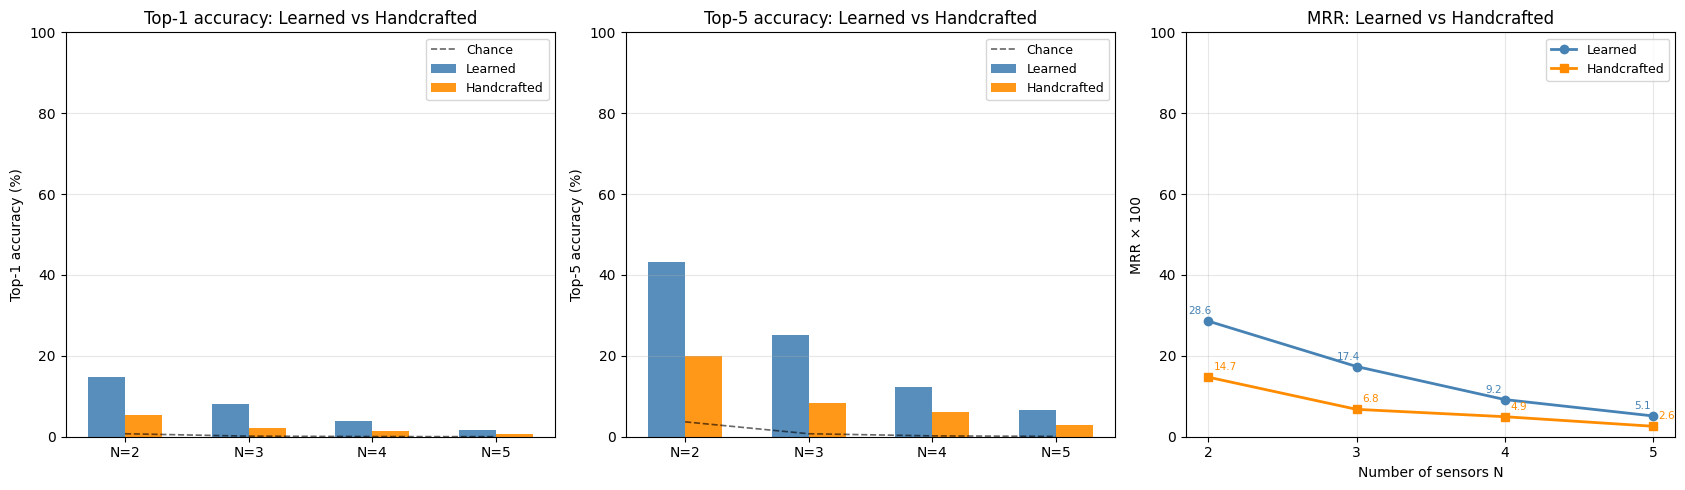


      ─── Pair retrieval (276 classes) ────────────────
  Approach         Top-1%   Top-5%   Top-10%      MRR
  ────────────────────────────────────────────
  Learned           21.80    59.59     76.37   0.3888
  Handcrafted        4.12    14.23     23.99   0.1091
  Chance             0.36     1.81      3.62   0.0036

  N  ─── N-sensor config ID ───────────────────────────────────────────────────────
  N   Configs   Lrn Top-1%   HC Top-1%   Lrn Top-5%   HC Top-5%   Lrn MRR    HC MRR
  ────────────────────────────────────────────────────────────────────────────────────
  2       136        14.86        5.42        43.15       20.05    0.2860    0.1473
  3       680         8.00        2.19        25.17        8.35    0.1736    0.0677
  4     2,380         3.86        1.50        12.35        6.02    0.0918    0.0495
  5     6,188         1.75        0.70         6.60        2.91    0.0514    0.0259


In [39]:
# ── Side-by-side comparison: Learned vs Handcrafted ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

Ns       = N_VALUES
lrn_top1 = [all_results[N]['top1'] for N in Ns]
lrn_top5 = [all_results[N]['top5'] for N in Ns]
lrn_mrr  = [all_results[N]['mrr'] * 100 for N in Ns]
hc_top1  = [hc_results[N]['top1']  for N in Ns]
hc_top5  = [hc_results[N]['top5']  for N in Ns]
hc_mrr   = [hc_results[N]['mrr']   * 100 for N in Ns]
chance1  = [all_results[N]['chance_top1'] for N in Ns]
chance5  = [all_results[N]['chance_top5'] for N in Ns]

x = np.arange(len(Ns))
w = 0.30

# ── Top-1 accuracy ────────────────────────────────────────────────────────
axes[0].bar(x - w/2, lrn_top1, w, label='Learned',       color='steelblue',   alpha=0.9)
axes[0].bar(x + w/2, hc_top1,  w, label='Handcrafted',   color='darkorange',  alpha=0.9)
axes[0].plot(x, chance1, 'k--', lw=1.2, label='Chance', alpha=0.6)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'N={n}' for n in Ns])
axes[0].set_ylabel('Top-1 accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].set_title('Top-1 accuracy: Learned vs Handcrafted')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# ── Top-5 accuracy ────────────────────────────────────────────────────────
axes[1].bar(x - w/2, lrn_top5, w, label='Learned',       color='steelblue',   alpha=0.9)
axes[1].bar(x + w/2, hc_top5,  w, label='Handcrafted',   color='darkorange',  alpha=0.9)
axes[1].plot(x, chance5, 'k--', lw=1.2, label='Chance', alpha=0.6)
axes[1].set_xticks(x); axes[1].set_xticklabels([f'N={n}' for n in Ns])
axes[1].set_ylabel('Top-5 accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].set_title('Top-5 accuracy: Learned vs Handcrafted')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

# ── MRR ───────────────────────────────────────────────────────────────────
axes[2].plot(Ns, lrn_mrr, 'o-', color='steelblue',  lw=2, label='Learned')
axes[2].plot(Ns, hc_mrr,  's-', color='darkorange',  lw=2, label='Handcrafted')
for n, l, h in zip(Ns, lrn_mrr, hc_mrr):
    axes[2].annotate(f'{l:.1f}', (n, l), textcoords='offset points', xytext=(-14, 5),
                     fontsize=7.5, color='steelblue')
    axes[2].annotate(f'{h:.1f}', (n, h), textcoords='offset points', xytext=(4, 5),
                     fontsize=7.5, color='darkorange')
axes[2].set_xticks(Ns)
axes[2].set_xlabel('Number of sensors N')
axes[2].set_ylabel('MRR × 100')
axes[2].set_ylim(0, 100)
axes[2].set_title('MRR: Learned vs Handcrafted')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print(f'\n{"":>4}  {"─── Pair retrieval (276 classes) ────────────────":^48}')
print(f'  {"Approach":<14}  {"Top-1%":>7}  {"Top-5%":>7}  {"Top-10%":>8}  {"MRR":>7}')
print('  ' + '─' * 44)
for label, t1, t5, t10, mrr in [
    ('Learned',       global_hits["top1"]/n_queries*100,
                      global_hits["top5"]/n_queries*100,
                      global_hits["top10"]/n_queries*100,
                      np.mean(all_rr)),
    ('Handcrafted',   hc_global_hits["top1"]/hc_n_queries*100,
                      hc_global_hits["top5"]/hc_n_queries*100,
                      hc_global_hits["top10"]/hc_n_queries*100,
                      np.mean(hc_all_rr)),
    ('Chance',        1/len(PAIRS)*100, 5/len(PAIRS)*100, 10/len(PAIRS)*100, 1/len(PAIRS)),
]:
    print(f'  {label:<14}  {t1:>7.2f}  {t5:>7.2f}  {t10:>8.2f}  {mrr:>7.4f}')

print()
print(f'{"N":>3}  {"─── N-sensor config ID ───────────────────────────────────────────────────────":^78}')
print(f'{"N":>3}  {"Configs":>8}  {"Lrn Top-1%":>11}  {"HC Top-1%":>10}  '
      f'{"Lrn Top-5%":>11}  {"HC Top-5%":>10}  {"Lrn MRR":>8}  {"HC MRR":>8}')
print('  ' + '─' * 84)
for N in Ns:
    r_l = all_results[N]
    r_h = hc_results[N]
    print(f'{N:>3}  {r_l["n_configs"]:>8,}  {r_l["top1"]:>11.2f}  {r_h["top1"]:>10.2f}  '
          f'{r_l["top5"]:>11.2f}  {r_h["top5"]:>10.2f}  '
          f'{r_l["mrr"]:>8.4f}  {r_h["mrr"]:>8.4f}')

Lift over chance  (how many × better than random guessing)

Pair retrieval  (276 classes,  chance top-1=0.36%)
  Metric        Chance     Learned      Lift    Handcrafted      Lift
  ——————————————————————————————————————————————————————————————
  Top-1 %        0.362       21.80     60.2x           4.12     11.4x
  Top-5 %        1.812       59.59     32.9x          14.23      7.9x
  MRR×100        0.362       38.88    107.3x          10.91     30.1x

N-sensor config ID
    N   Configs   Chance%    Lrn T1     Lift     HC T1     Lift    Lrn MRR     Lift     HC MRR     Lift
  -----------------------------------------------------------------------------------------------
    2       136     0.735     14.86    20.2x      5.42     7.4x      28.60    38.9x      14.73    20.0x
    3       680     0.147      8.00    54.4x      2.19    14.9x      17.36   118.1x       6.77    46.1x
    4     2,380     0.042      3.86    91.8x      1.50    35.6x       9.18   218.6x       4.95   117.8x
    5     

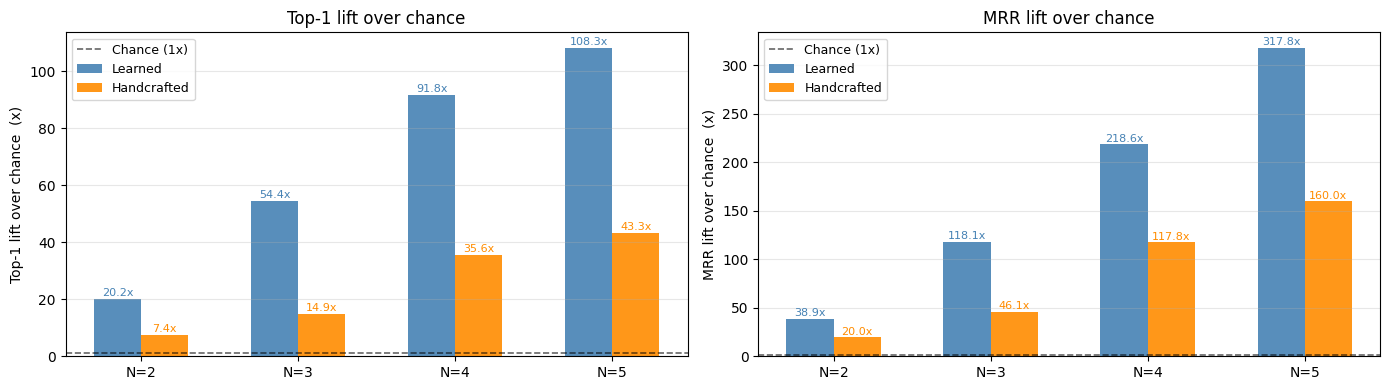

In [40]:
# ── Lift over chance ──────────────────────────────────────────────────────
# "Lift" = metric_value / chance_baseline
# pair retrieval uses 276 classes; N-sensor uses C(17,N) classes

print('Lift over chance  (how many × better than random guessing)')
print('=' * 66)

# ── Pair retrieval (all 276 pairs) ────────────────────────────────────────
chance_pair_top1 = 1 / len(PAIRS) * 100
chance_pair_top5 = 5 / len(PAIRS) * 100
chance_pair_mrr  = 1 / len(PAIRS)          # MRR×100 at chance ≈ 1/N_classes

lrn_pair_top1 = global_hits['top1'] / n_queries * 100
lrn_pair_top5 = global_hits['top5'] / n_queries * 100
lrn_pair_mrr  = np.mean(all_rr)

hc_pair_top1 = hc_global_hits['top1'] / hc_n_queries * 100
hc_pair_top5 = hc_global_hits['top5'] / hc_n_queries * 100
hc_pair_mrr  = np.mean(hc_all_rr)

print(f'\nPair retrieval  ({len(PAIRS)} classes,  chance top-1={chance_pair_top1:.2f}%)')
print(f'  {"Metric":<10}  {"Chance":>8}  {"Learned":>10}  {"Lift":>8}  '
      f'{"Handcrafted":>13}  {"Lift":>8}')
print('  ' + chr(8212) * 62)
for metric, chance, lrn, hc in [
    ('Top-1 %',  chance_pair_top1, lrn_pair_top1, hc_pair_top1),
    ('Top-5 %',  chance_pair_top5, lrn_pair_top5, hc_pair_top5),
    ('MRR×100',  chance_pair_mrr * 100, lrn_pair_mrr * 100, hc_pair_mrr * 100),
]:
    print(f'  {metric:<10}  {chance:>8.3f}  {lrn:>10.2f}  {lrn/chance:>7.1f}x  '
          f'{hc:>13.2f}  {hc/chance:>7.1f}x')

# ── N-sensor config ID ────────────────────────────────────────────────────
print(f'\nN-sensor config ID')
print(f'  {"N":>3}  {"Configs":>8}  {"Chance%":>8}  '
      f'{"Lrn T1":>8}  {"Lift":>7}  '
      f'{"HC T1":>8}  {"Lift":>7}  '
      f'{"Lrn MRR":>9}  {"Lift":>7}  '
      f'{"HC MRR":>9}  {"Lift":>7}')
print('  ' + '-' * 95)
for N in N_VALUES:
    r_l   = all_results[N]
    r_h   = hc_results[N]
    c1    = r_l['chance_top1']
    c_mrr = 100.0 / r_l['n_configs']
    print(f'  {N:>3}  {r_l["n_configs"]:>8,}  {c1:>8.3f}  '
          f'{r_l["top1"]:>8.2f}  {r_l["top1"]/c1:>6.1f}x  '
          f'{r_h["top1"]:>8.2f}  {r_h["top1"]/c1:>6.1f}x  '
          f'{r_l["mrr"]*100:>9.2f}  {r_l["mrr"]*100/c_mrr:>6.1f}x  '
          f'{r_h["mrr"]*100:>9.2f}  {r_h["mrr"]*100/c_mrr:>6.1f}x')

# ── Bar chart: lift over chance ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

Ns = N_VALUES
lrn_lifts_t1  = [all_results[N]['top1'] / all_results[N]['chance_top1'] for N in Ns]
hc_lifts_t1   = [hc_results[N]['top1']  / hc_results[N]['chance_top1']  for N in Ns]
lrn_lifts_mrr = [all_results[N]['mrr'] * 100 / (100.0 / all_results[N]['n_configs']) for N in Ns]
hc_lifts_mrr  = [hc_results[N]['mrr']  * 100 / (100.0 / hc_results[N]['n_configs'])  for N in Ns]

x = np.arange(len(Ns))
w = 0.30

axes[0].bar(x - w/2, lrn_lifts_t1, w, label='Learned',     color='steelblue',  alpha=0.9)
axes[0].bar(x + w/2, hc_lifts_t1,  w, label='Handcrafted', color='darkorange', alpha=0.9)
axes[0].axhline(1, color='k', lw=1.2, ls='--', label='Chance (1x)', alpha=0.6)
for xi, (l, h) in enumerate(zip(lrn_lifts_t1, hc_lifts_t1)):
    axes[0].text(xi - w/2, l + 0.3, f'{l:.1f}x', ha='center', va='bottom', fontsize=8, color='steelblue')
    axes[0].text(xi + w/2, h + 0.3, f'{h:.1f}x', ha='center', va='bottom', fontsize=8, color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels([f'N={n}' for n in Ns])
axes[0].set_ylabel('Top-1 lift over chance  (x)')
axes[0].set_title('Top-1 lift over chance')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, lrn_lifts_mrr, w, label='Learned',     color='steelblue',  alpha=0.9)
axes[1].bar(x + w/2, hc_lifts_mrr,  w, label='Handcrafted', color='darkorange', alpha=0.9)
axes[1].axhline(1, color='k', lw=1.2, ls='--', label='Chance (1x)', alpha=0.6)
for xi, (l, h) in enumerate(zip(lrn_lifts_mrr, hc_lifts_mrr)):
    axes[1].text(xi - w/2, l + 0.3, f'{l:.1f}x', ha='center', va='bottom', fontsize=8, color='steelblue')
    axes[1].text(xi + w/2, h + 0.3, f'{h:.1f}x', ha='center', va='bottom', fontsize=8, color='darkorange')
axes[1].set_xticks(x); axes[1].set_xticklabels([f'N={n}' for n in Ns])
axes[1].set_ylabel('MRR lift over chance  (x)')
axes[1].set_title('MRR lift over chance')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
